In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']      = 11
sns.set_style('whitegrid')

from sklearn.preprocessing   import StandardScaler, MinMaxScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute           import SimpleImputer
from sklearn.model_selection  import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline         import Pipeline
from sklearn.utils            import resample

from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import (RandomForestClassifier, GradientBoostingClassifier,
                                       AdaBoostClassifier, BaggingClassifier)
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.naive_bayes      import GaussianNB

from sklearn.linear_model     import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree             import DecisionTreeRegressor
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm              import SVR

from sklearn.cluster          import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture          import GaussianMixture
from sklearn.decomposition    import PCA
from scipy.cluster.hierarchy  import dendrogram, linkage

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

In [ ]:
# Dataset load karo
df = pd.read_csv('Data/education loan.csv')

print(f' Dataset load ho gaya!')
print(f'\nShape : {df.shape[0]} rows{df.shape[1]} columns')

 Dataset load ho gaya!

Shape : 300 rows21 columns


In [ ]:
# pehli 5 rows
df.head()

,name,age,academic_score,entrance_score,course_level,course_stream,institute_tier,country,parent_income,parent_existing_emi,...,parent_cibil,tuition_fee,living_expenses,down_payment,loan_amount_requested,tenure_years,moratorium_years,loan_status,approved_amount,interest_rate
0,Aaditya Gupta,23.0,75.35,405.000000,UG,Law,Tier3,India,14940.0,3104.0,...,748.0,583269.0,176765.000000,23703.0,736331.0,9.797101,2.000000,1.0,533657.0,12.750000
1,Meera Gupta,NaN,83.52,590.000000,PG,Law,Tier2,India,43837.0,3593.0,...,771.0,1384480.0,96980.000000,96142.0,1385318.0,9.797101,1.000000,1.0,NaN,12.330000
2,Kunal Reddy,NaN,71.49,552.373188,PhD,Other,Tier2,India,8000.0,2809.0,...,830.0,506706.0,69243.000000,132008.0,443941.0,NaN,1.644928,1.0,321996.0,12.750000
3,Rohan Patel,24.0,65.43,569.000000,PG,Arts,NaN,UK,67332.0,23690.0,...,675.0,4216367.0,708494.000000,1171893.0,3752968.0,5.000000,1.644928,0.0,0.0,12.316355
4,Shruti Yadav,23.0,94.36,530.000000,PG,Arts,Tier2,India,67082.0,NaN,...,663.0,1346198.0,293180.007246,169470.0,1322428.0,10.000000,2.000000,0.0,0.0,12.316355


In [ ]:
# data types & non-null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   280 non-null    object 
 1   age                    283 non-null    float64
 2   academic_score         283 non-null    float64
 3   entrance_score         285 non-null    float64
 4   course_level           282 non-null    object 
 5   course_stream          288 non-null    object 
 6   institute_tier         284 non-null    object 
 7   country                283 non-null    object 
 8   parent_income          290 non-null    float64
 9   parent_existing_emi    295 non-null    float64
 10  parent_dti             282 non-null    float64
 11  parent_cibil           280 non-null    float64
 12  tuition_fee            288 non-null    float64
 13  living_expenses        289 non-null    float64
 14  down_payment           290 non-null    float64
 15  loan_a

In [ ]:
# numerical aur categorical columns alag identify karo
numerical_cols   = df.select_dtypes(include=['float64','int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f' Numerical Columns  ({len(numerical_cols)}) : {numerical_cols}')
print(f'\n Categorical Columns ({len(categorical_cols)}) : {categorical_cols}')

 Numerical Columns  (16) : ['age', 'academic_score', 'entrance_score', 'parent_income', 'parent_existing_emi', 'parent_dti', 'parent_cibil', 'tuition_fee', 'living_expenses', 'down_payment', 'loan_amount_requested', 'tenure_years', 'moratorium_years', 'loan_status', 'approved_amount', 'interest_rate']

 Categorical Columns (5) : ['name', 'course_level', 'course_stream', 'institute_tier', 'country']


In [ ]:
# categorical columns ki unique categories
for col in categorical_cols:
    vals = df[col].dropna().unique()
    vc   = df[col].value_counts().to_dict()
    print(f'\n {col}  ({len(vals)} unique):')
    print(f'Values : {sorted(vals.tolist())}')
    print(f'Counts : {vc}')


 name  (152 unique):
Values : ['Aaditya Gupta', 'Aaditya Jain', 'Aaditya Kapoor', 'Aaditya Khan', 'Aaditya Patel', 'Aaditya Reddy', 'Aaditya Sharma', 'Aaditya Singh', 'Aaditya Verma', 'Amit Jain', 'Amit Kapoor', 'Amit Patel', 'Amit Sharma', 'Amit Singh', 'Amit Verma', 'Amit Yadav', 'Anjali Gupta', 'Anjali Jain', 'Anjali Kapoor', 'Anjali Khan', 'Anjali Patel', 'Anjali Reddy', 'Anjali Sharma', 'Anjali Singh', 'Anjali Verma', 'Anjali Yadav', 'Kabir Gupta', 'Kabir Jain', 'Kabir Kapoor', 'Kabir Khan', 'Kabir Patel', 'Kabir Reddy', 'Kabir Singh', 'Kabir Yadav', 'Kiran Gupta', 'Kiran Kapoor', 'Kiran Khan', 'Kiran Patel', 'Kiran Reddy', 'Kiran Sharma', 'Kiran Yadav', 'Kunal Jain', 'Kunal Kapoor', 'Kunal Khan', 'Kunal Reddy', 'Kunal Sharma', 'Kunal Singh', 'Kunal Verma', 'Kunal Yadav', 'Meera Gupta', 'Meera Jain', 'Meera Kapoor', 'Meera Khan', 'Meera Patel', 'Meera Sharma', 'Meera Singh', 'Meera Verma', 'Mohit Gupta', 'Mohit Kapoor', 'Mohit Khan', 'Mohit Reddy', 'Mohit Sharma', 'Mohit Singh', 

In [ ]:
# missing values – count aur percentage
missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(' Missing Value Report:\n')
print(missing.to_string())

 Missing Value Report:

                       Missing Count  Missing %
name                              20       6.67
parent_cibil                      20       6.67
course_level                      18       6.00
parent_dti                        18       6.00
country                           17       5.67
age                               17       5.67
academic_score                    17       5.67
loan_amount_requested             16       5.33
institute_tier                    16       5.33
loan_status                       16       5.33
tenure_years                      16       5.33
entrance_score                    15       5.00
moratorium_years                  15       5.00
interest_rate                     15       5.00
course_stream                     12       4.00
approved_amount                   12       4.00
tuition_fee                       12       4.00
living_expenses                   11       3.67
down_payment                      10       3.33
parent_income   

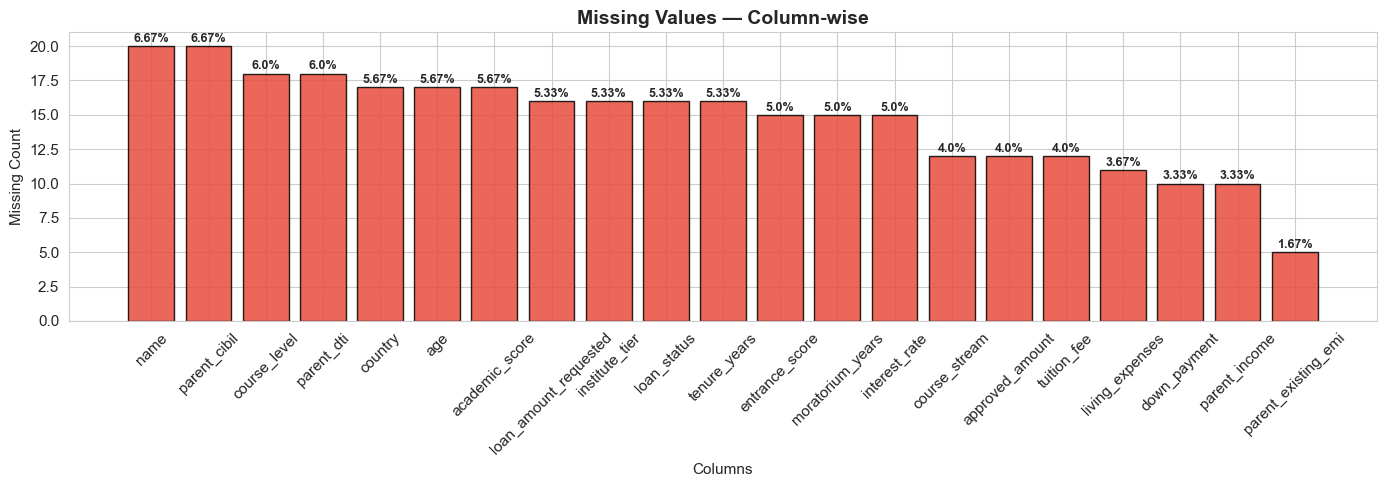

In [ ]:
# missing values bar chart
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(missing.index, missing['Missing Count'], color='#E74C3C', edgecolor='black', alpha=0.85)

for bar, pct in zip(bars, missing['Missing %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct}%', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Missing Values — Column-wise', fontsize=14, fontweight='bold')
ax.set_xlabel('Columns')
ax.set_ylabel('Missing Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# IQR method se outlier count karo
outlier_rows = []
for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5*IQR
    hi  = Q3 + 1.5*IQR
    n   = df[(df[col] < lo) | (df[col] > hi)][col].count()
    outlier_rows.append({'Column': col, 'Lower': round(lo,2),
                         'Upper': round(hi,2), 'Outliers': n,
                         'Outlier %': round(n/df[col].count()*100,2)})

outlier_df = pd.DataFrame(outlier_rows).sort_values('Outliers', ascending=False)
print('Outlier Summary (IQR Method):\n')
print(outlier_df.to_string(index=False))

Outlier Summary (IQR Method):

               Column      Lower      Upper  Outliers  Outlier %
        interest_rate      11.77      12.81        42      14.74
loan_amount_requested -470332.17 2402098.29        36      12.68
      living_expenses -119285.01  540659.02        32      11.07
          tuition_fee -671088.00 2462482.00        29      10.07
      approved_amount -934295.88 2009101.12        25       8.68
         down_payment -183646.38  430066.62        20       6.90
  parent_existing_emi  -12813.50   34754.50         6       2.03
         parent_cibil     565.62     862.62         3       1.07
        parent_income   -4691.75  121920.25         1       0.34
                  age       6.50      42.50         0       0.00
       academic_score      45.64     109.40         0       0.00
       entrance_score     161.50     957.50         0       0.00
           parent_dti      -0.15       0.55         0       0.00
         tenure_years      -0.50      19.50         0      

In [ ]:
# descriptive statistics – extended (skewness, kurtosis)
desc = df[numerical_cols].describe().T.round(2)
desc['skewness'] = df[numerical_cols].skew().round(3)
desc['kurtosis'] = df[numerical_cols].kurt().round(3)
desc

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,283.0,24.92,5.21,17.00,20.00,24.96,29.00,34.00,0.109,-1.160
academic_score,283.0,77.59,9.66,60.48,69.54,77.82,85.48,94.86,-0.007,-1.003
entrance_score,285.0,552.25,132.50,301.00,460.00,552.37,659.00,799.00,-0.065,-0.883
parent_income,290.0,59505.86,22974.13,8000.00,42787.75,59719.17,74440.75,126580.00,0.252,-0.028
parent_existing_emi,295.0,11956.42,8660.40,49.00,5024.50,11281.00,16916.50,40625.00,0.835,0.467
parent_dti,282.0,0.20,0.11,0.00,0.11,0.20,0.29,0.40,-0.048,-1.026
parent_cibil,280.0,716.36,57.31,550.00,677.00,718.04,751.25,883.00,0.088,0.178
tuition_fee,288.0,1181676.63,1089583.52,102063.00,504000.75,997644.50,1287393.25,5612048.00,2.267,5.147
living_expenses,289.0,290652.66,297752.39,50163.00,128194.00,214761.00,293180.01,1488131.00,2.561,5.946
down_payment,290.0,166247.50,188708.79,10.00,46496.00,122212.00,199924.25,1324640.00,2.948,11.559


---


### 2.1 Univariate — Numerical Columns (Histograms)

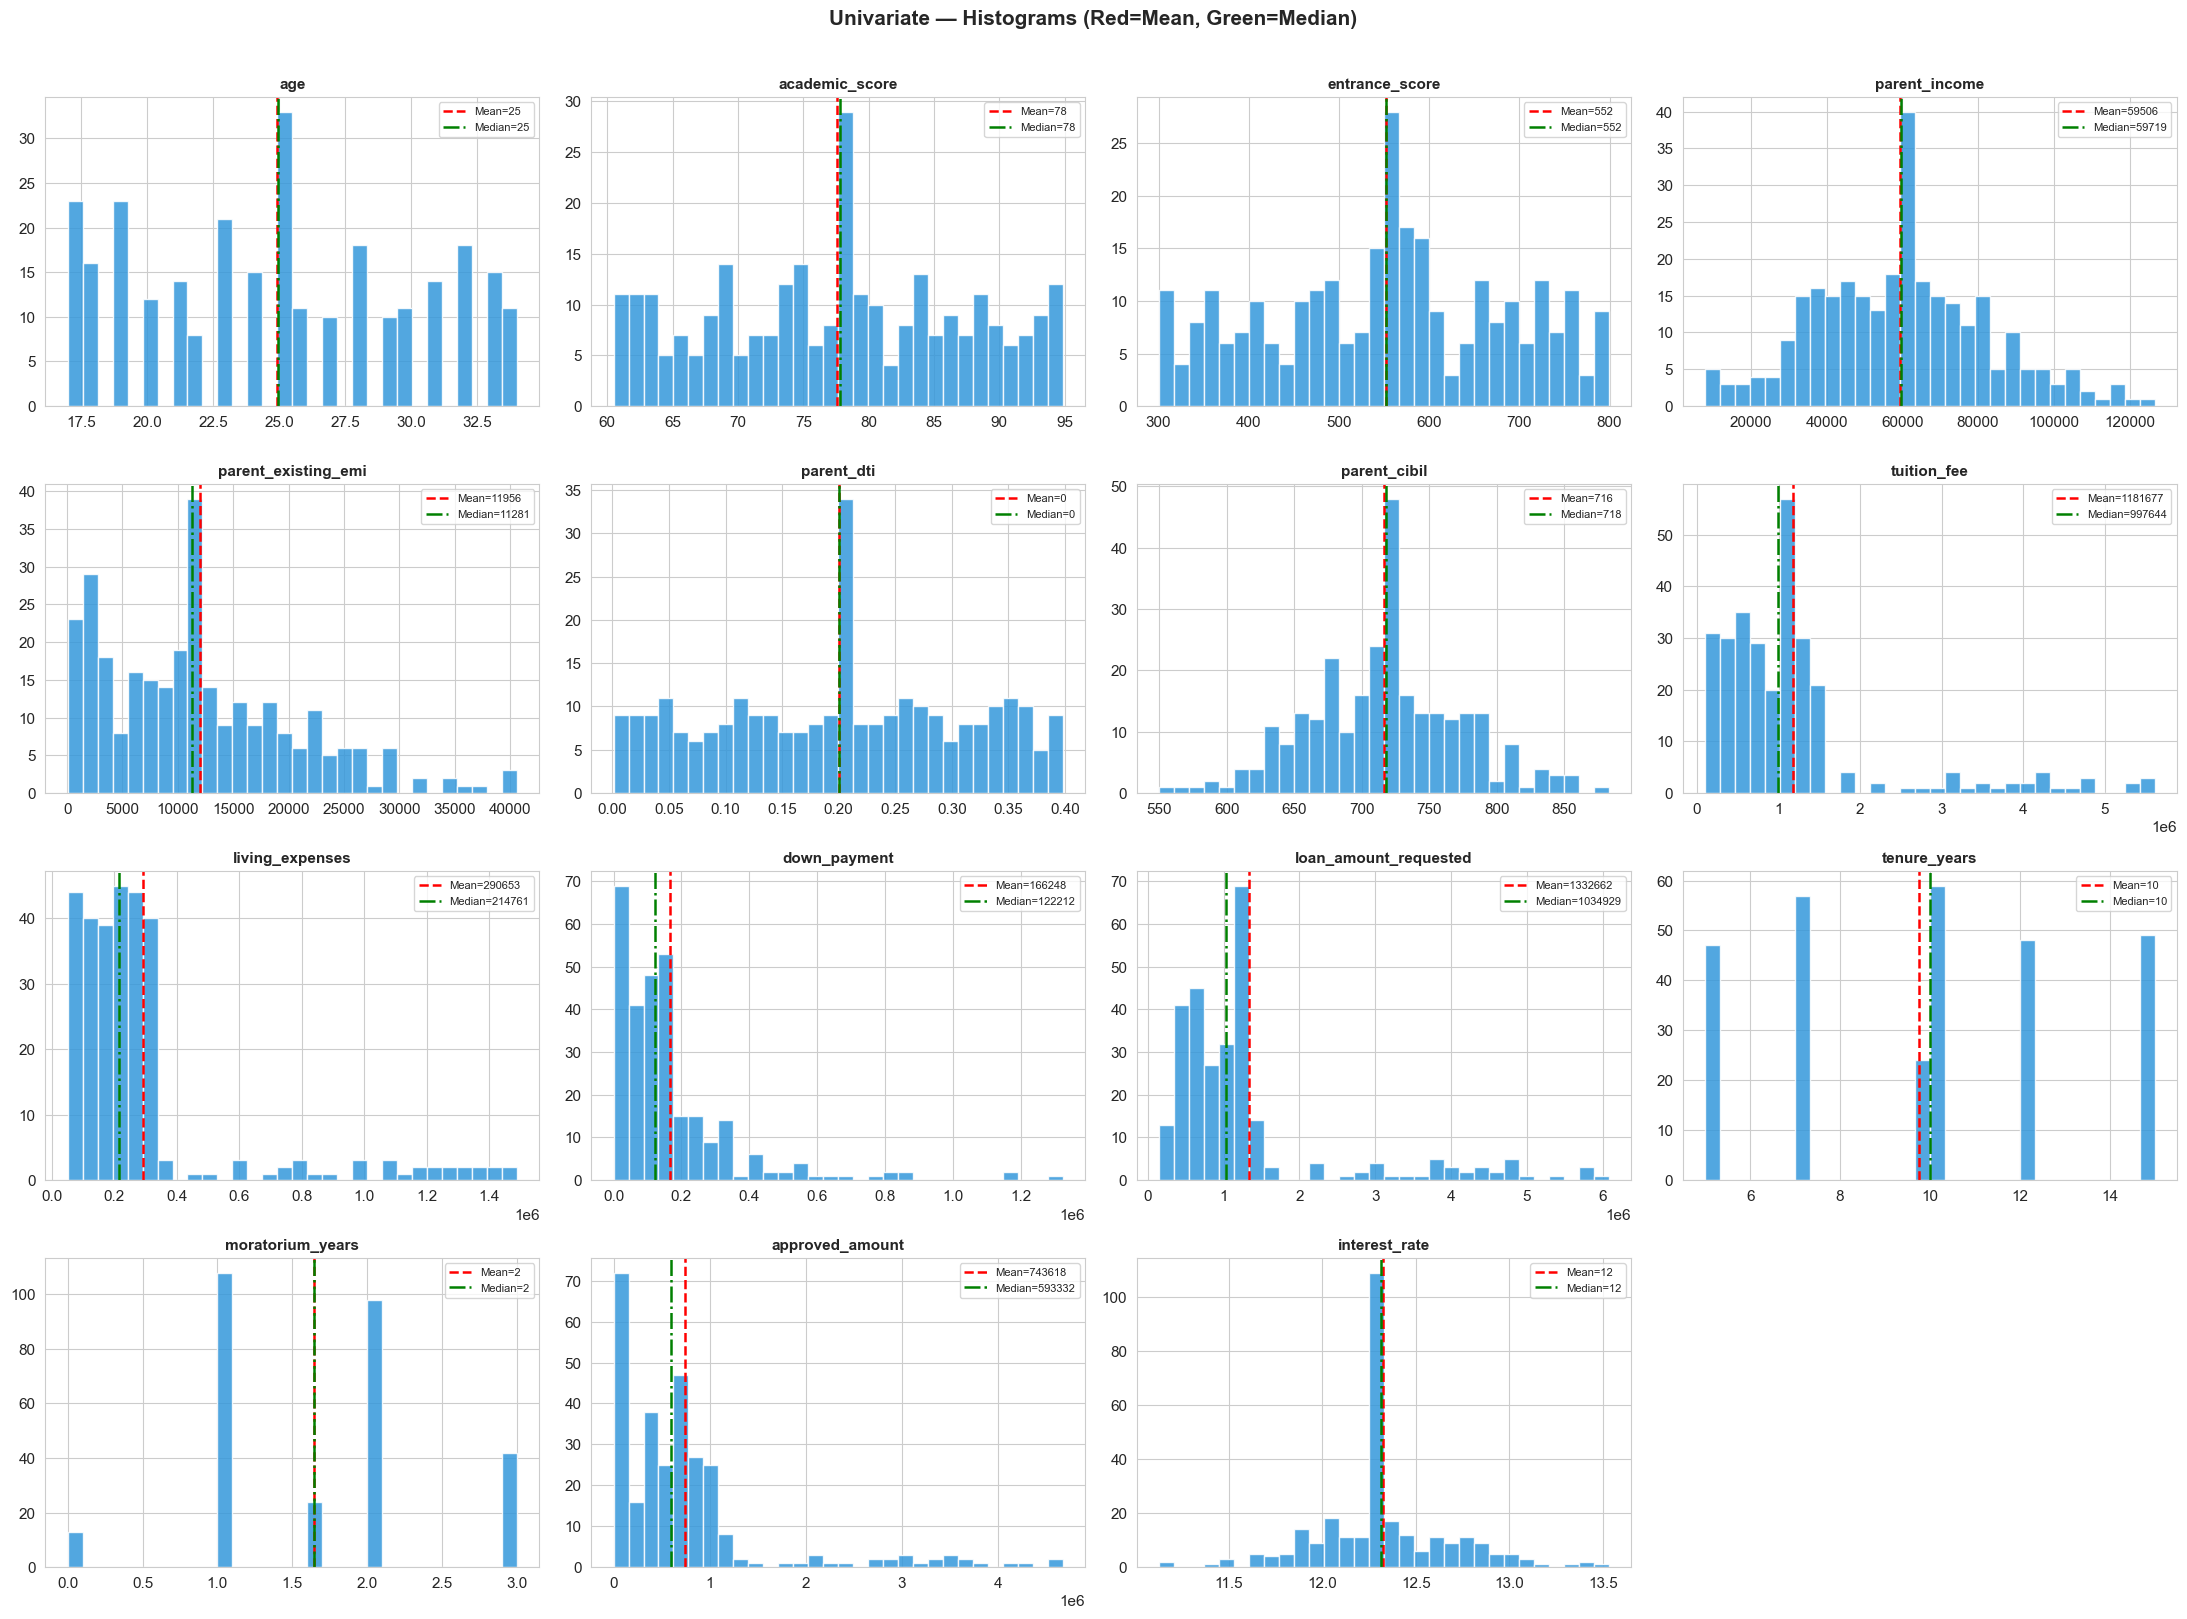

In [ ]:
# sabhi numerical columns ke histograms
cols_to_plot = [c for c in numerical_cols if c != 'loan_status']
n_c = 4
n_r = (len(cols_to_plot) + n_c - 1) // n_c

fig, axes = plt.subplots(n_r, n_c, figsize=(22, n_r*4))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col].dropna(), bins=30, color='#3498DB', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='red',   linestyle='--', lw=1.8, label=f'Mean={df[col].mean():.0f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='-.',  lw=1.8, label=f'Median={df[col].median():.0f}')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate — Histograms (Red=Mean, Green=Median)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Univariate — Numerical Columns (Boxplots)

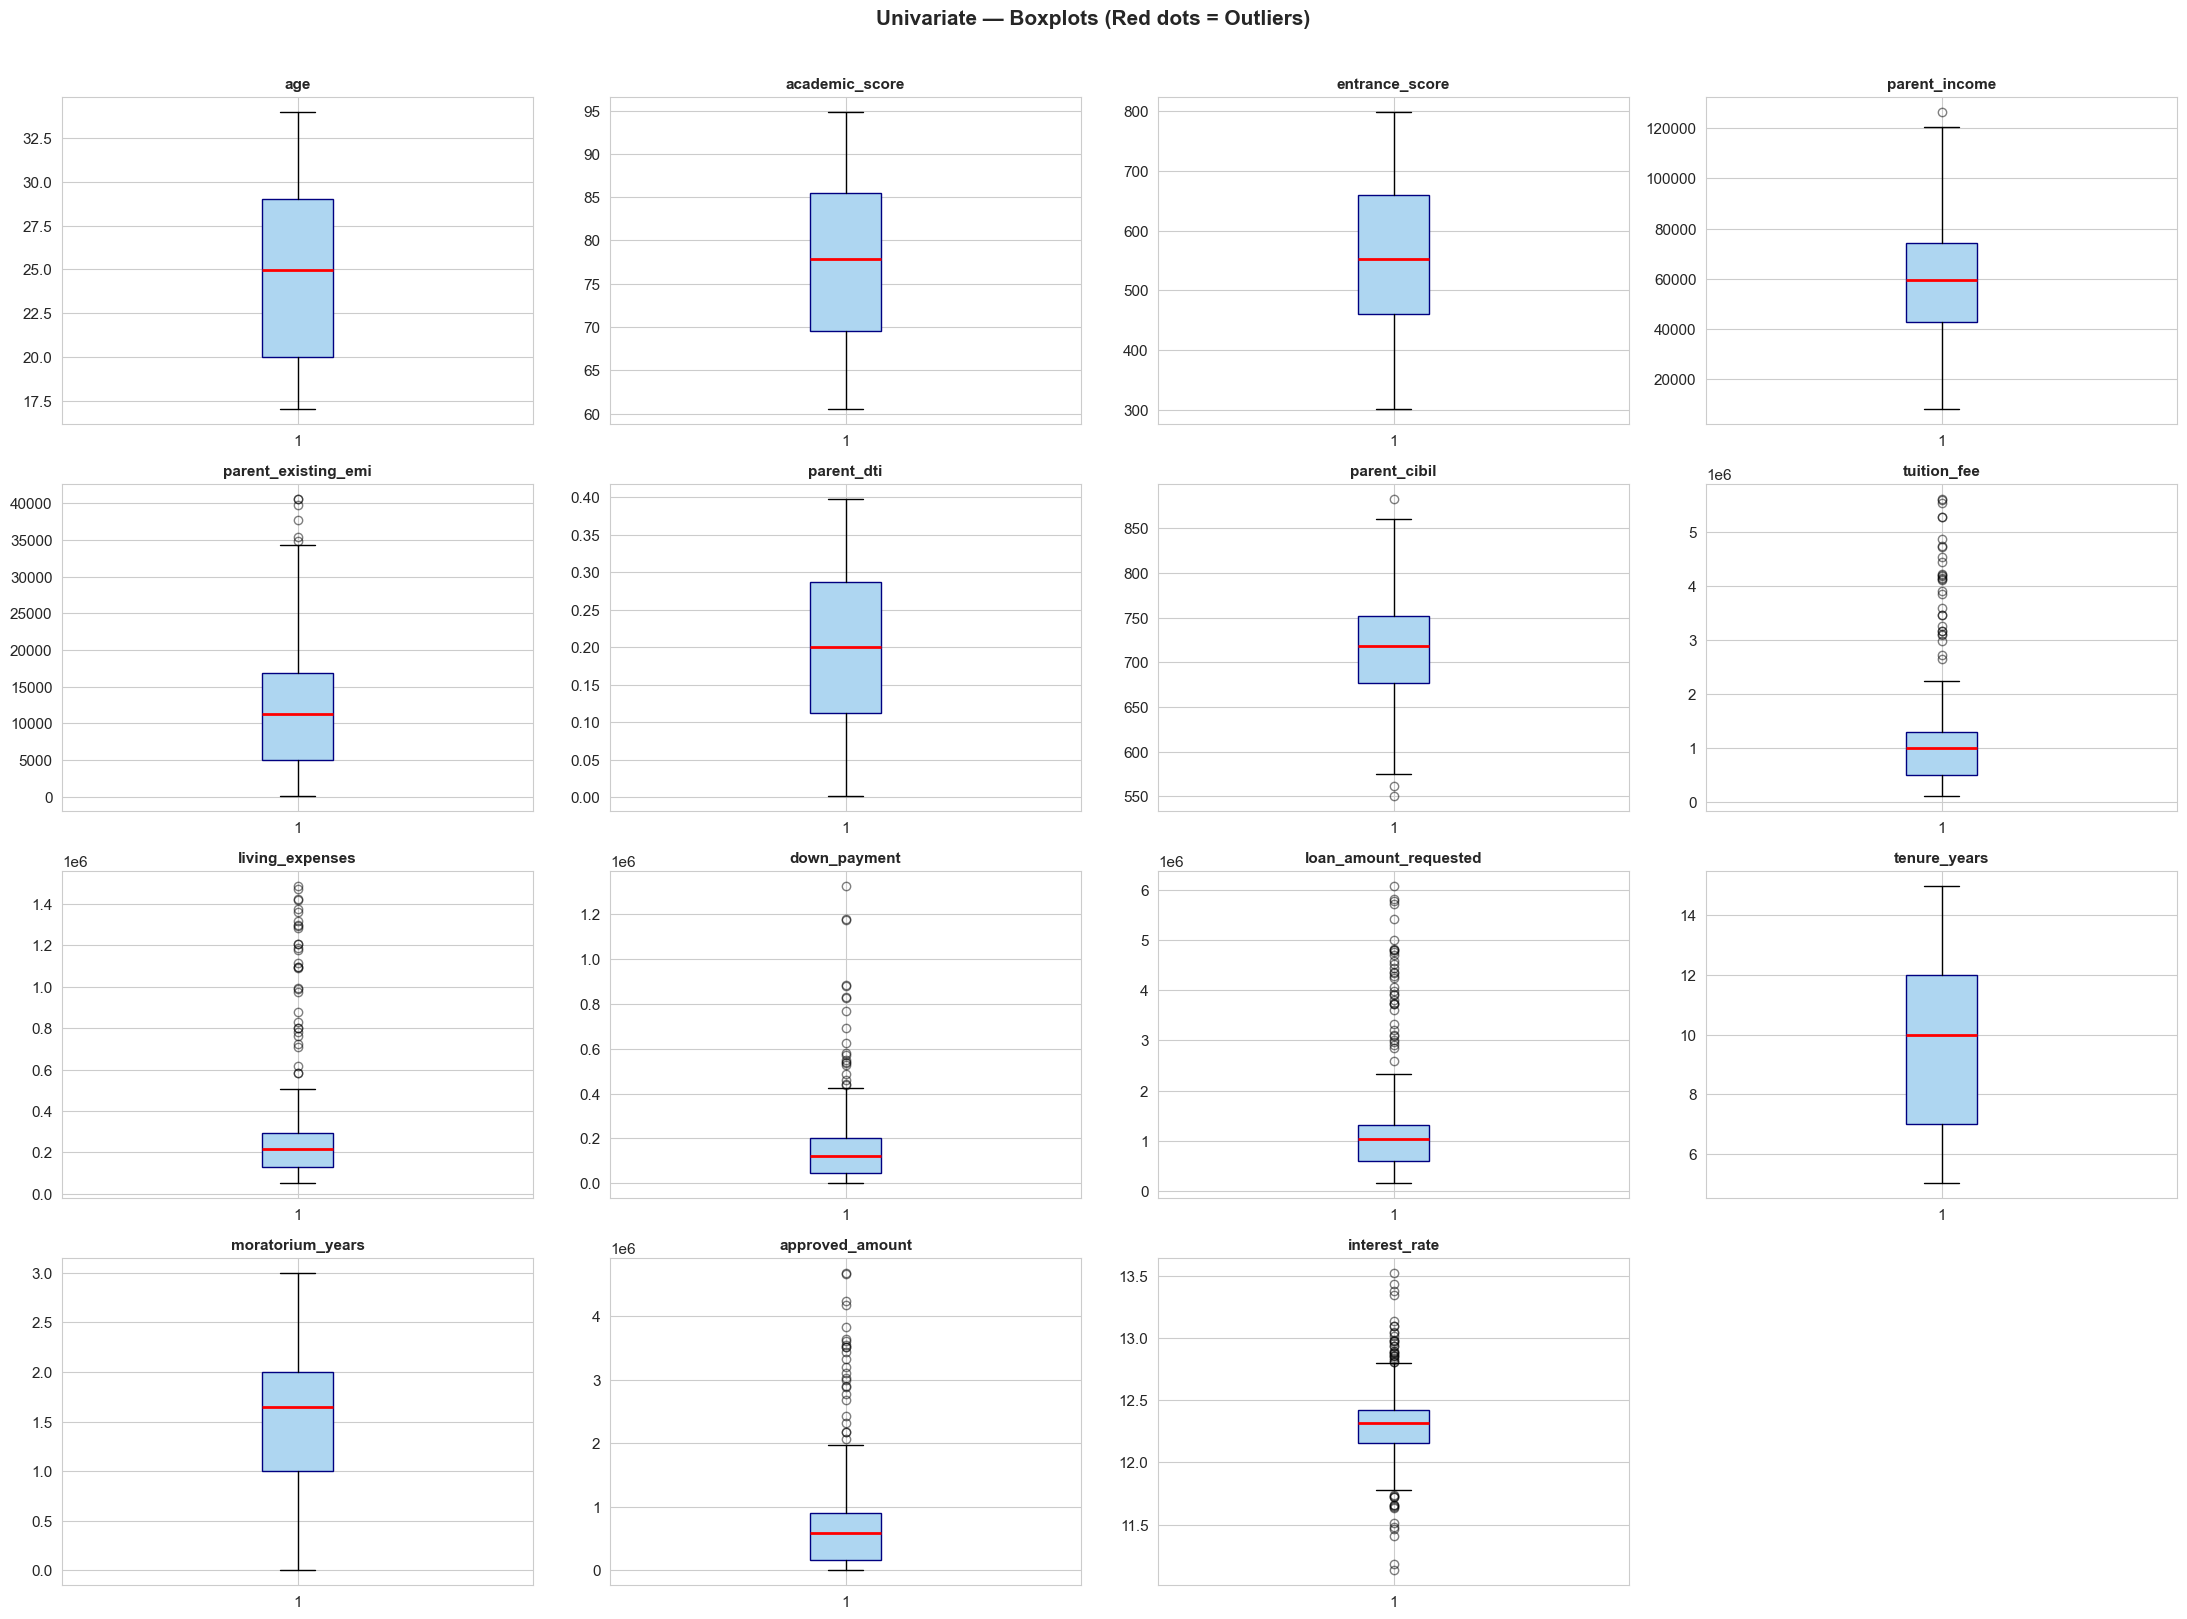

In [ ]:
# boxplots – outliers red dots mein dikhenge
fig, axes = plt.subplots(n_r, n_c, figsize=(22, n_r*4))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops   =dict(facecolor='#AED6F1', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops =dict(marker='o', color='red', alpha=0.5))
    axes[i].set_title(col, fontsize=11, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate — Boxplots (Red dots = Outliers)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Univariate — Categorical Columns

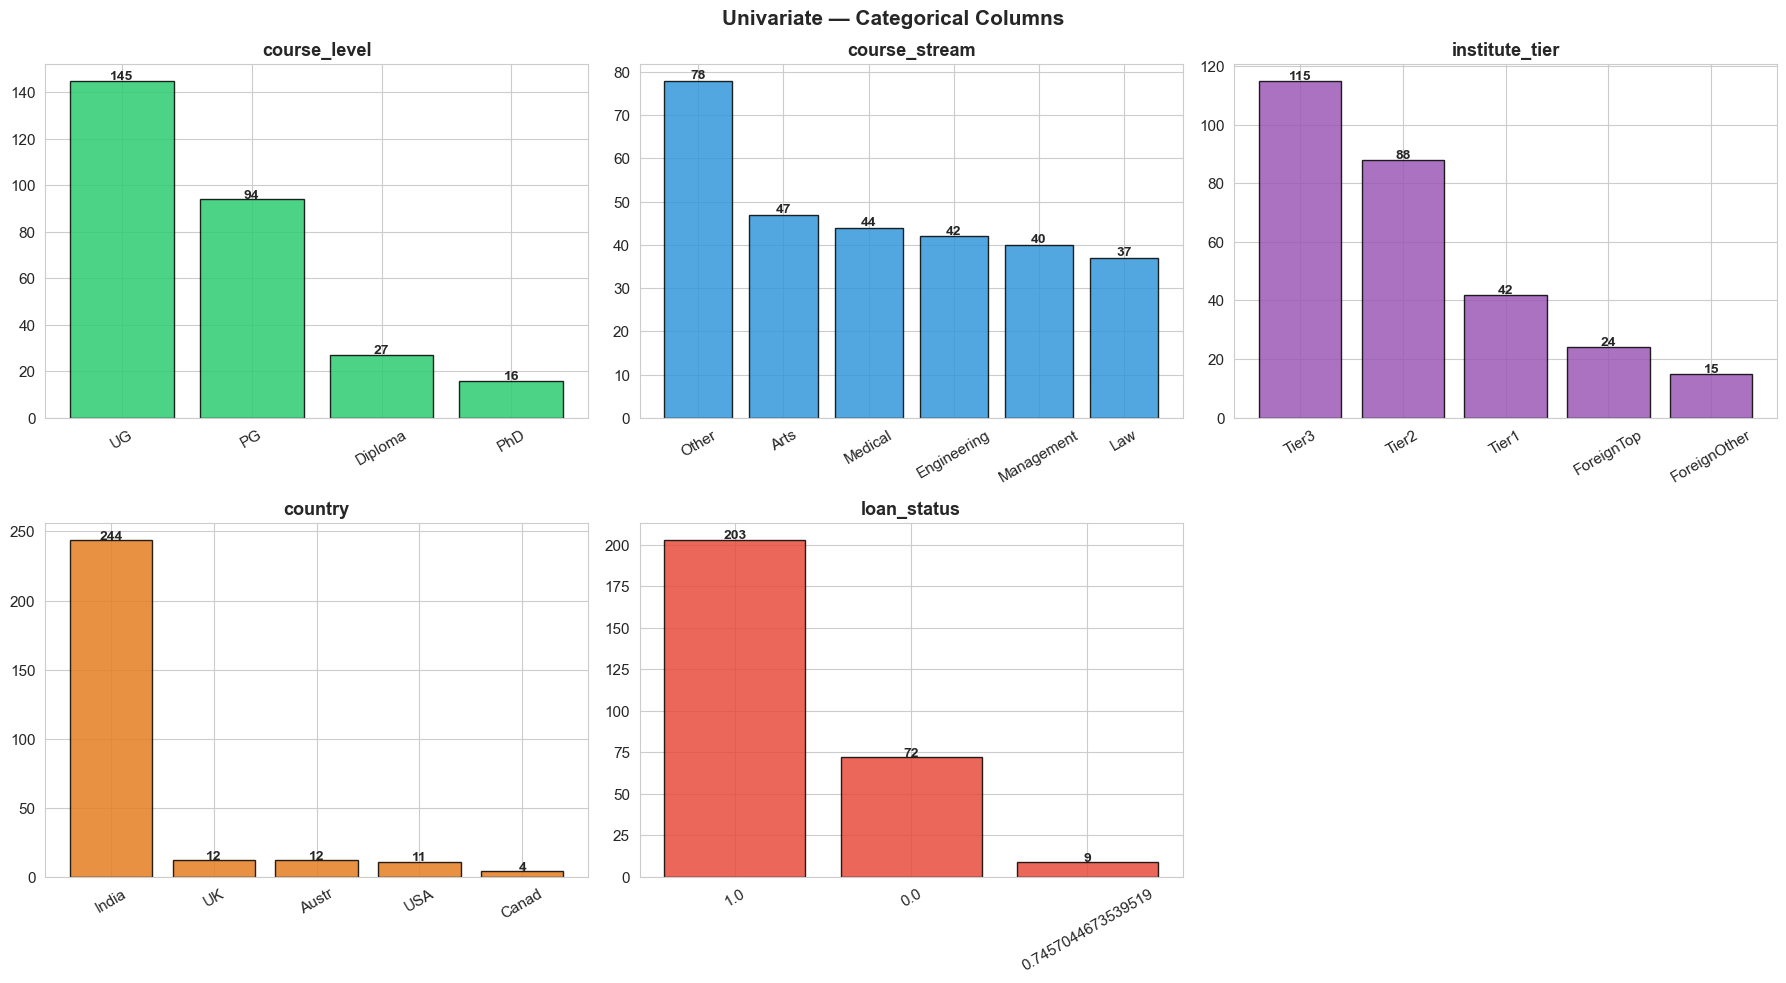

In [ ]:
# categorical columns ke bar charts
cat_plot = ['course_level', 'course_stream', 'institute_tier', 'country', 'loan_status']
palette  = ['#2ECC71','#3498DB','#9B59B6','#E67E22','#E74C3C']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_plot):
    vc = df[col].value_counts()
    bars = axes[i].bar(vc.index.astype(str), vc.values,
                       color=palette[i], edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vc.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     str(v), ha='center', fontsize=10, fontweight='bold')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.suptitle('Univariate — Categorical Columns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Bivariate — Categorical vs Target (loan_status)

In [ ]:
# Approval Rate % – institute tier aur country ke liye
for col in ['institute_tier', 'course_level', 'country']:
    rate = df.groupby(col)['loan_status'].mean().mul(100).round(1).sort_values(ascending=False)
    print(f'\nApproval Rate % by {col}:')
    print(rate.to_string())


Approval Rate % by institute_tier:
institute_tier
ForeignOther    82.7
Tier2           76.5
Tier3           72.9
Tier1           70.8
ForeignTop      66.7

Approval Rate % by course_level:
course_level
PG         75.5
UG         75.0
Diploma    73.1
PhD        69.6

Approval Rate % by country:
country
Canad    100.0
Austr     75.0
India     74.9
USA       67.5
UK        63.6


### 2.5 Bivariate — Numerical vs Target (loan_status)

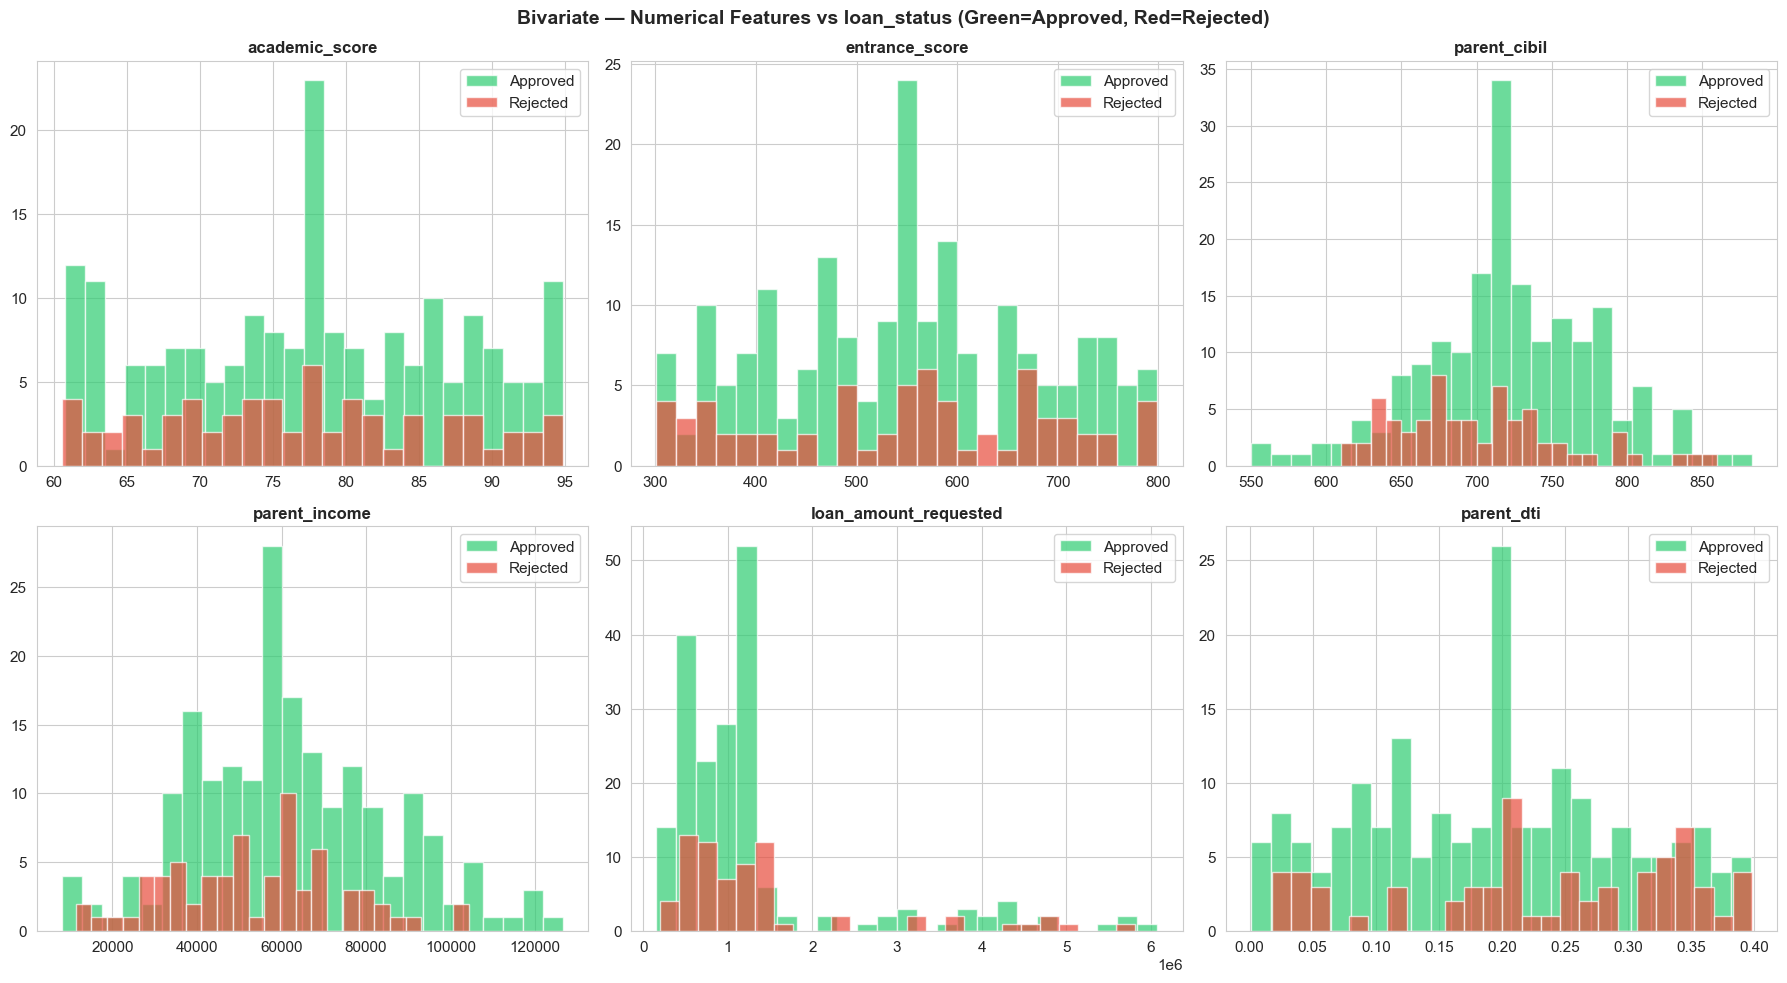

In [ ]:
# numerical features ka distribution – approved vs rejected
num_bi = ['academic_score', 'entrance_score', 'parent_cibil',
          'parent_income', 'loan_amount_requested', 'parent_dti']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_bi):
    approved = df[df['loan_status']==1][col].dropna()
    rejected = df[df['loan_status']==0][col].dropna()
    axes[i].hist(approved, bins=25, alpha=0.7, color='#2ECC71', label='Approved')
    axes[i].hist(rejected, bins=25, alpha=0.7, color='#E74C3C', label='Rejected')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend()

plt.suptitle('Bivariate — Numerical Features vs loan_status (Green=Approved, Red=Rejected)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

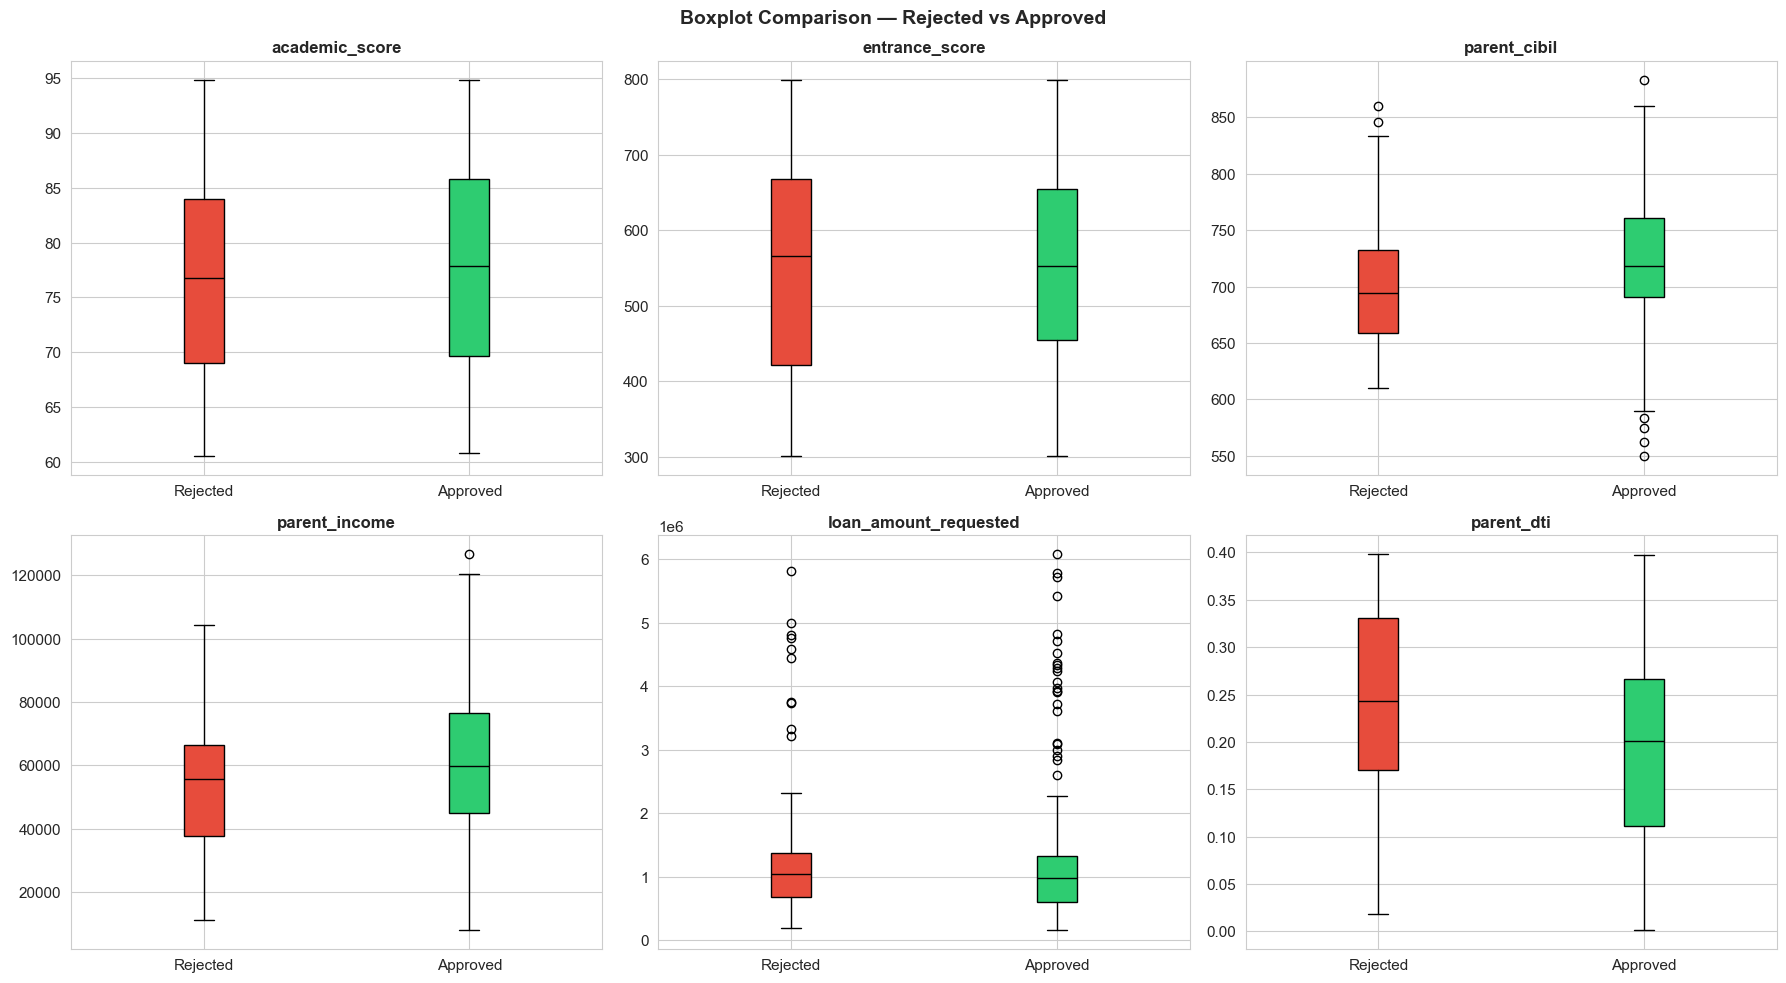

In [ ]:
# Boxplot — approved vs rejected comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

df_nonan = df.dropna(subset=['loan_status'])

for i, col in enumerate(num_bi):
    data_0 = df_nonan[df_nonan['loan_status']==0][col].dropna()
    data_1 = df_nonan[df_nonan['loan_status']==1][col].dropna()
    bp = axes[i].boxplot([data_0, data_1], patch_artist=True,
                         labels=['Rejected','Approved'])
    bp['boxes'][0].set_facecolor('#E74C3C')
    bp['boxes'][1].set_facecolor('#2ECC71')
    for median in bp['medians']:
        median.set_color('black')
    axes[i].set_title(col, fontsize=12, fontweight='bold')

plt.suptitle('Boxplot Comparison — Rejected vs Approved', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Multivariate — Correlation Heatmap

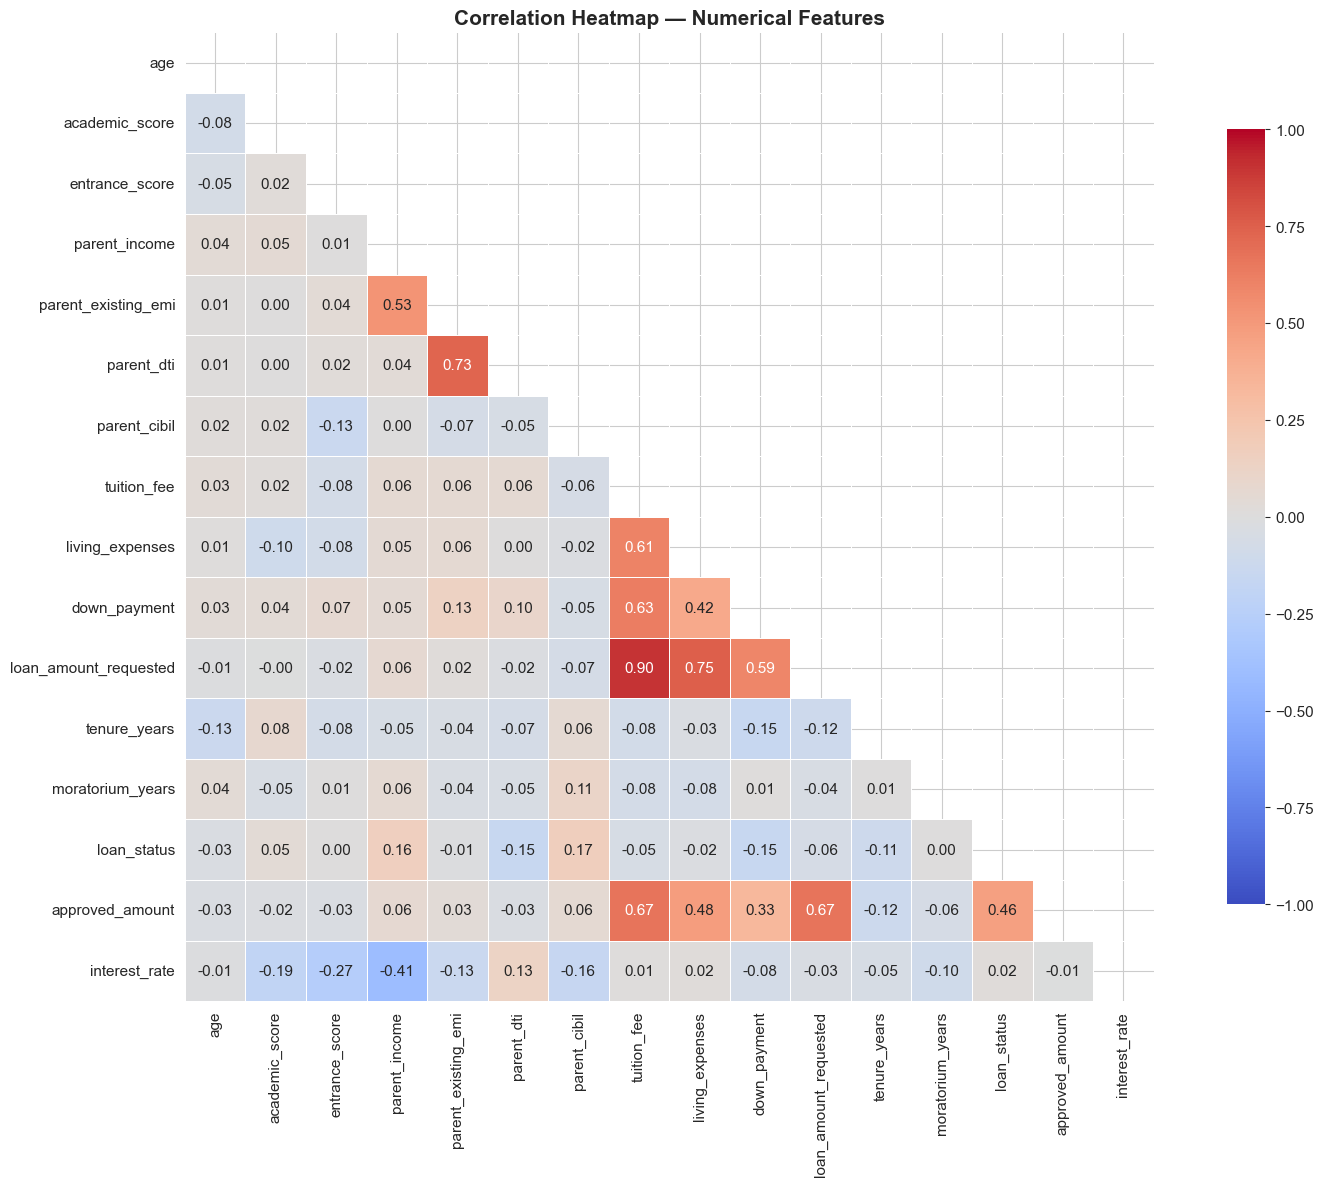

In [ ]:
# full correlation heatmap
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

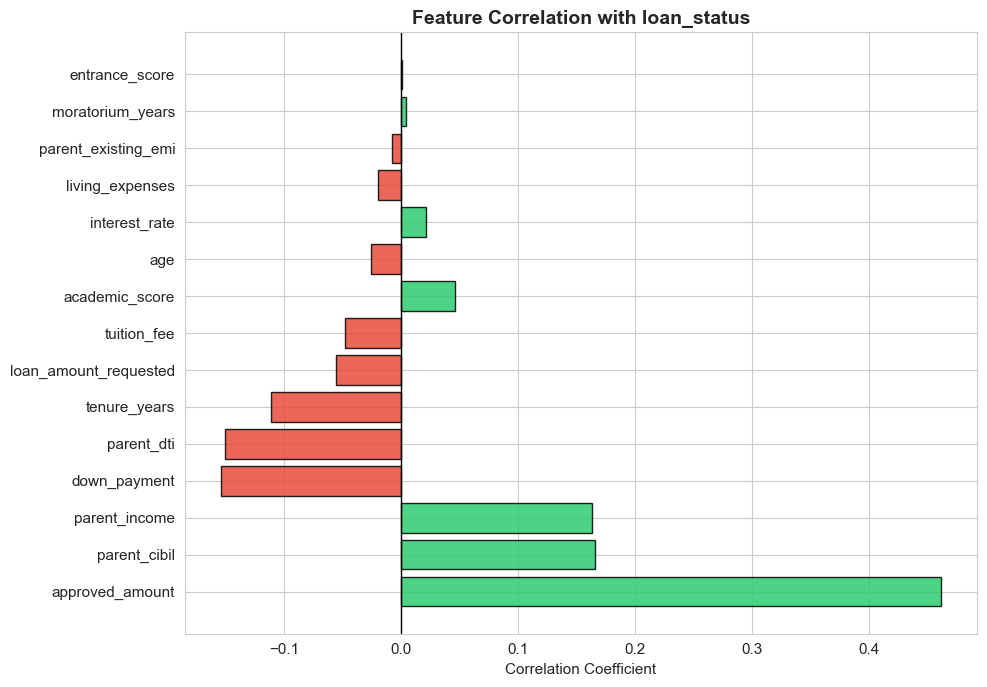

approved_amount          0.461436
parent_cibil             0.166043
parent_income            0.162952
down_payment            -0.154038
parent_dti              -0.150492
tenure_years            -0.111447
loan_amount_requested   -0.056020
tuition_fee             -0.048030
academic_score           0.046143
age                     -0.025881
interest_rate            0.021205
living_expenses         -0.019506
parent_existing_emi     -0.008041
moratorium_years         0.004422
entrance_score           0.000999
Name: loan_status, dtype: float64


In [ ]:
# target ke saath sabse zyaada correlated features
target_corr = (df[numerical_cols].corr()['loan_status']
               .drop('loan_status')
               .sort_values(key=abs, ascending=False))

clrs = ['#2ECC71' if v > 0 else '#E74C3C' for v in target_corr.values]

plt.figure(figsize=(10, 7))
plt.barh(target_corr.index, target_corr.values, color=clrs, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', lw=1)
plt.title('Feature Correlation with loan_status', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()
print(target_corr)

### 2.7 Bivariate — Scatter Plots (Key Features)

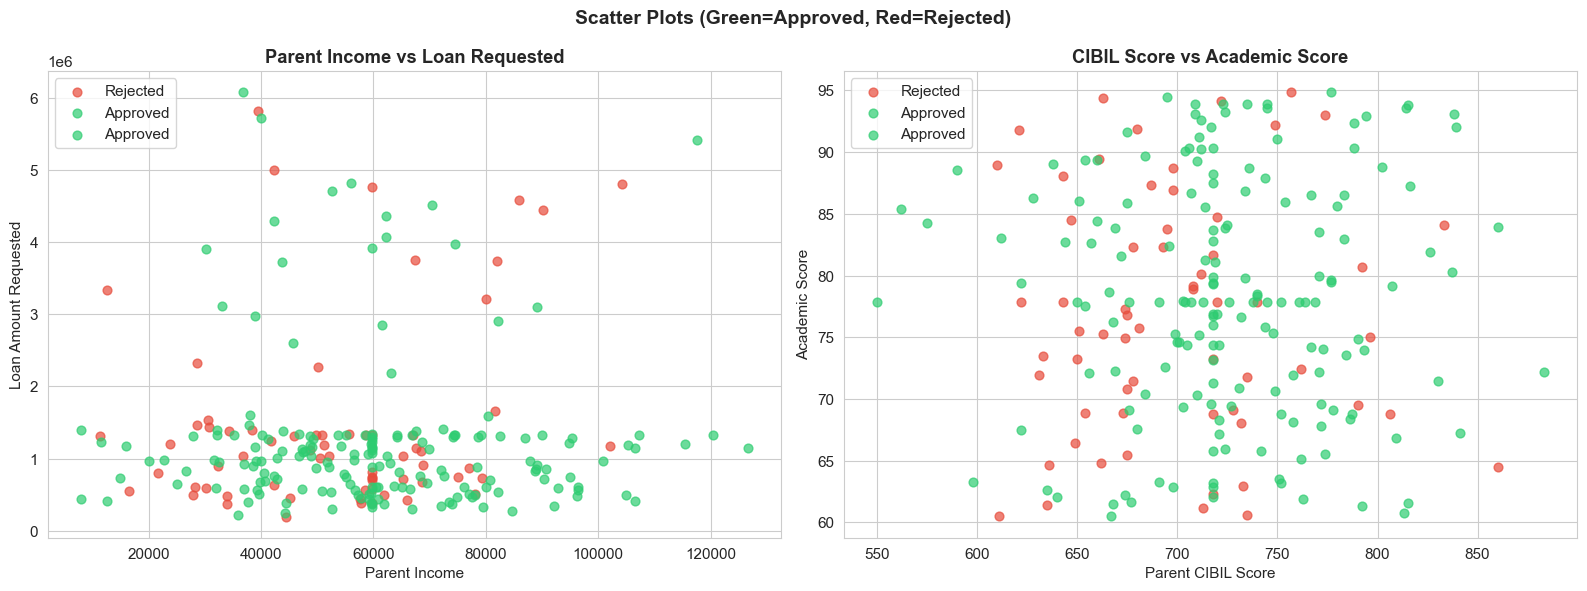

In [ ]:
# parent_income vs loan_amount_requested — color = loan_status
df_clean = df.dropna(subset=['loan_status','parent_income','loan_amount_requested','parent_cibil'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_map = {1: '#2ECC71', 0: '#E74C3C'}

for status, grp in df_clean.groupby('loan_status'):
    label = 'Approved' if status >= 0.5 else 'Rejected'
    color = colors_map[1 if status >= 0.5 else 0]   # ← fix here
    axes[0].scatter(grp['parent_income'], grp['loan_amount_requested'],
                    c=color, label=label, alpha=0.7, s=40)

axes[0].set_xlabel('Parent Income')
axes[0].set_ylabel('Loan Amount Requested')
axes[0].set_title('Parent Income vs Loan Requested', fontweight='bold')
axes[0].legend()

for status, grp in df_clean.groupby('loan_status'):
    label = 'Approved' if status >= 0.5 else 'Rejected'
    color = colors_map[1 if status >= 0.5 else 0]   # ← fix here
    axes[1].scatter(grp['parent_cibil'], grp['academic_score'],
                    c=color, label=label, alpha=0.7, s=40)

axes[1].set_xlabel('Parent CIBIL Score')
axes[1].set_ylabel('Academic Score')
axes[1].set_title('CIBIL Score vs Academic Score', fontweight='bold')
axes[1].legend()

plt.suptitle('Scatter Plots (Green=Approved, Red=Rejected)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

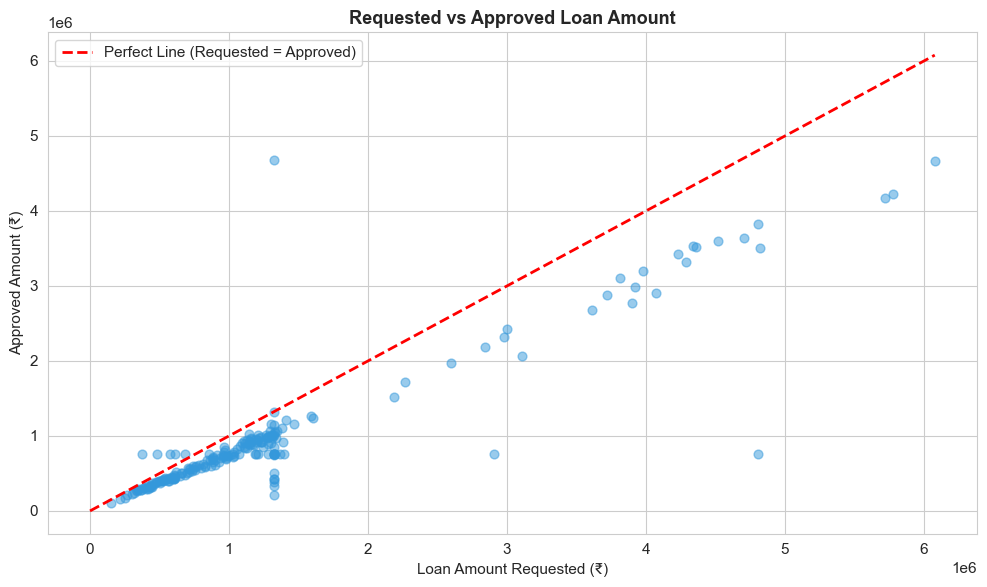

In [ ]:
# loan_amount_requested vs approved_amount — gap kitna hai
df_ap = df.dropna(subset=['loan_amount_requested','approved_amount'])
df_ap = df_ap[df_ap['approved_amount'] > 0]  # sirf approved

plt.figure(figsize=(10, 6))
plt.scatter(df_ap['loan_amount_requested'], df_ap['approved_amount'],
            alpha=0.5, color='#3498DB', s=40)
max_val = max(df_ap['loan_amount_requested'].max(), df_ap['approved_amount'].max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Line (Requested = Approved)')
plt.xlabel('Loan Amount Requested (₹)')
plt.ylabel('Approved Amount (₹)')
plt.title('Requested vs Approved Loan Amount', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 2.8 Multivariate — Pairplot (Top Features)

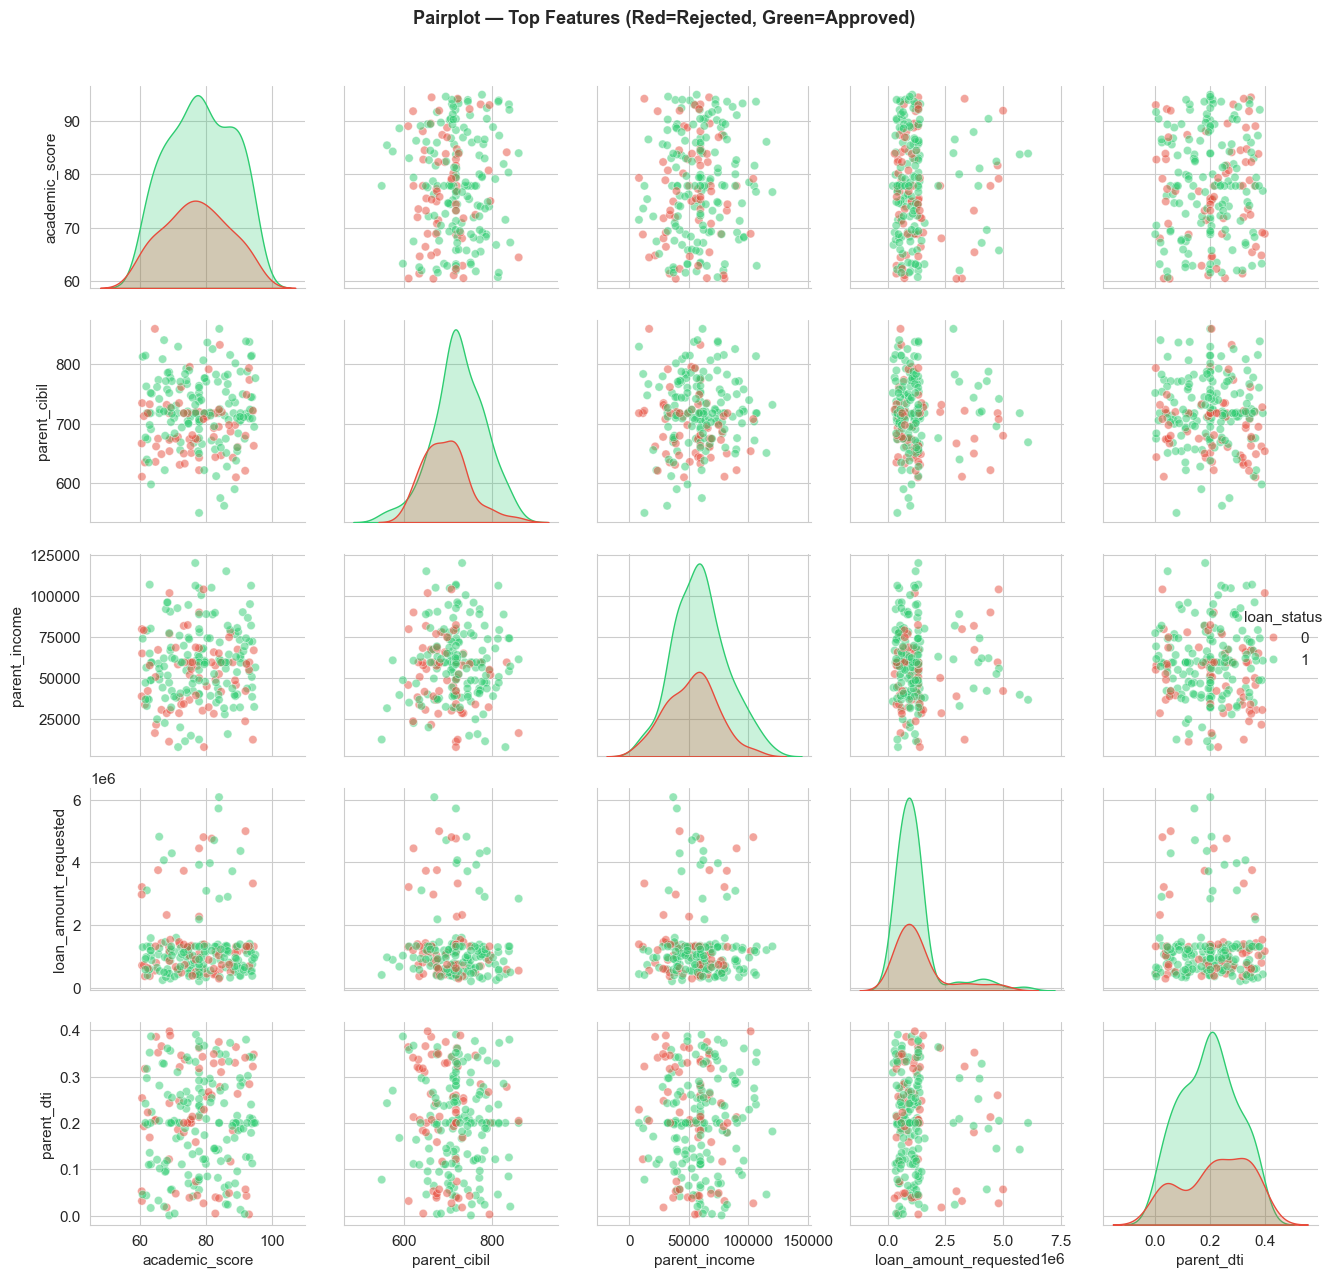

In [ ]:
# pairplot — top 5 important features + target
pair_cols = ['academic_score','parent_cibil','parent_income',
             'loan_amount_requested','parent_dti','loan_status']

df_pair = df[pair_cols].dropna()
df_pair['loan_status'] = df_pair['loan_status'].astype(int)

g = sns.pairplot(df_pair, hue='loan_status',
                 palette={0: '#E74C3C', 1: '#2ECC71'},
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pairplot — Top Features (Red=Rejected, Green=Approved)',
               y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Data Preprocessing & Cleaning

In [ ]:
# original df ko preserve karte hain — alag copy pe kaam karenge
df_raw = df.copy()
df     = df.copy()
print(f'Original shape  : {df_raw.shape}')
print(f'Working copy    : {df.shape}')

Original shape  : (300, 21)
Working copy    : (300, 21)


### 3.2 loan_status = NaN → Unseen data alag karo

In [ ]:
# target variable missing hai jinhe baad mein predict karenge
df_unseen = df[df['loan_status'].isna()].copy()
df        = df[df['loan_status'].notna()].copy()

print(f'Unseen (predict later) : {df_unseen.shape[0]} rows')
print(f'Training data          : {df.shape[0]} rows')

Unseen (predict later) : 16 rows
Training data          : 284 rows


### 3.3 Completely blank rows drop karo

In [ ]:
# jo rows mein 15 se zyaada columns blank hain unhe drop karo
before = df.shape[0]
df = df[df.isnull().sum(axis=1) < 15].copy()
after  = df.shape[0]

print(f'Rows before drop : {before}')
print(f'Rows dropped     : {before - after}')
print(f'Rows after drop  : {after}')

Rows before drop : 284
Rows dropped     : 0
Rows after drop  : 284


### 3.4 `name` column drop karo

In [ ]:
# naam sirf identifier hai, ML mein kaam ka nahi
df.drop(columns=['name'], inplace=True)
print(f'Columns after drop name: {df.shape[1]}')
print(df.columns.tolist())

Columns after drop name: 20
['age', 'academic_score', 'entrance_score', 'course_level', 'course_stream', 'institute_tier', 'country', 'parent_income', 'parent_existing_emi', 'parent_dti', 'parent_cibil', 'tuition_fee', 'living_expenses', 'down_payment', 'loan_amount_requested', 'tenure_years', 'moratorium_years', 'loan_status', 'approved_amount', 'interest_rate']


### 3.5 Missing values impute karo — Numerical

In [ ]:
# numerical columns — median imputation (outlier-resistant)
num_cols_impute = ['age','academic_score','entrance_score',
                   'parent_income','parent_existing_emi','parent_dti',
                   'parent_cibil','tuition_fee','living_expenses',
                   'down_payment','loan_amount_requested',
                   'tenure_years','moratorium_years','approved_amount']

for col in num_cols_impute:
    med = df[col].median()
    df[col].fillna(med, inplace=True)

In [ ]:
# interest_rate — approved ke liye median, rejected ke liye 0
median_rate = df[df['loan_status']==1]['interest_rate'].median()

df.loc[(df['loan_status']==1) & (df['interest_rate'].isna()), 'interest_rate'] = median_rate
df.loc[(df['loan_status']==0) & (df['interest_rate'].isna()), 'interest_rate'] = 0.0

print(f'interest_rate missing remaining : {df["interest_rate"].isna().sum()}')

interest_rate missing remaining : 0


### 3.6 Missing values impute karo — Categorical

In [ ]:
# categorical columns — mode imputation
cat_cols_impute = ['course_level','course_stream','institute_tier','country']

for col in cat_cols_impute:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f'  {col} → filled with mode = "{mode_val}"')

  course_level → filled with mode = "UG"
  course_stream → filled with mode = "Other"
  institute_tier → filled with mode = "Tier3"
  country → filled with mode = "India"


In [ ]:
# check karo — ab koi missing bacha toh nahi
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print('Koi bhi missing value nahi bachi!')
else:
    print('Still missing:')
    print(remaining)

Koi bhi missing value nahi bachi!


### 3.7 Outlier Treatment — Log Transformation

In [ ]:
# highly skewed columns ko log transform karo
# np.log1p() = log(1+x) — zero values safe rehti hain
log_cols = ['tuition_fee','living_expenses','loan_amount_requested',
            'approved_amount','down_payment','parent_income']

for col in log_cols:
    df[f'log_{col}'] = np.log1p(df[col])

print(f'Log transformed columns banaye gaye:')
print([f'log_{c}' for c in log_cols])

Log transformed columns banaye gaye:
['log_tuition_fee', 'log_living_expenses', 'log_loan_amount_requested', 'log_approved_amount', 'log_down_payment', 'log_parent_income']


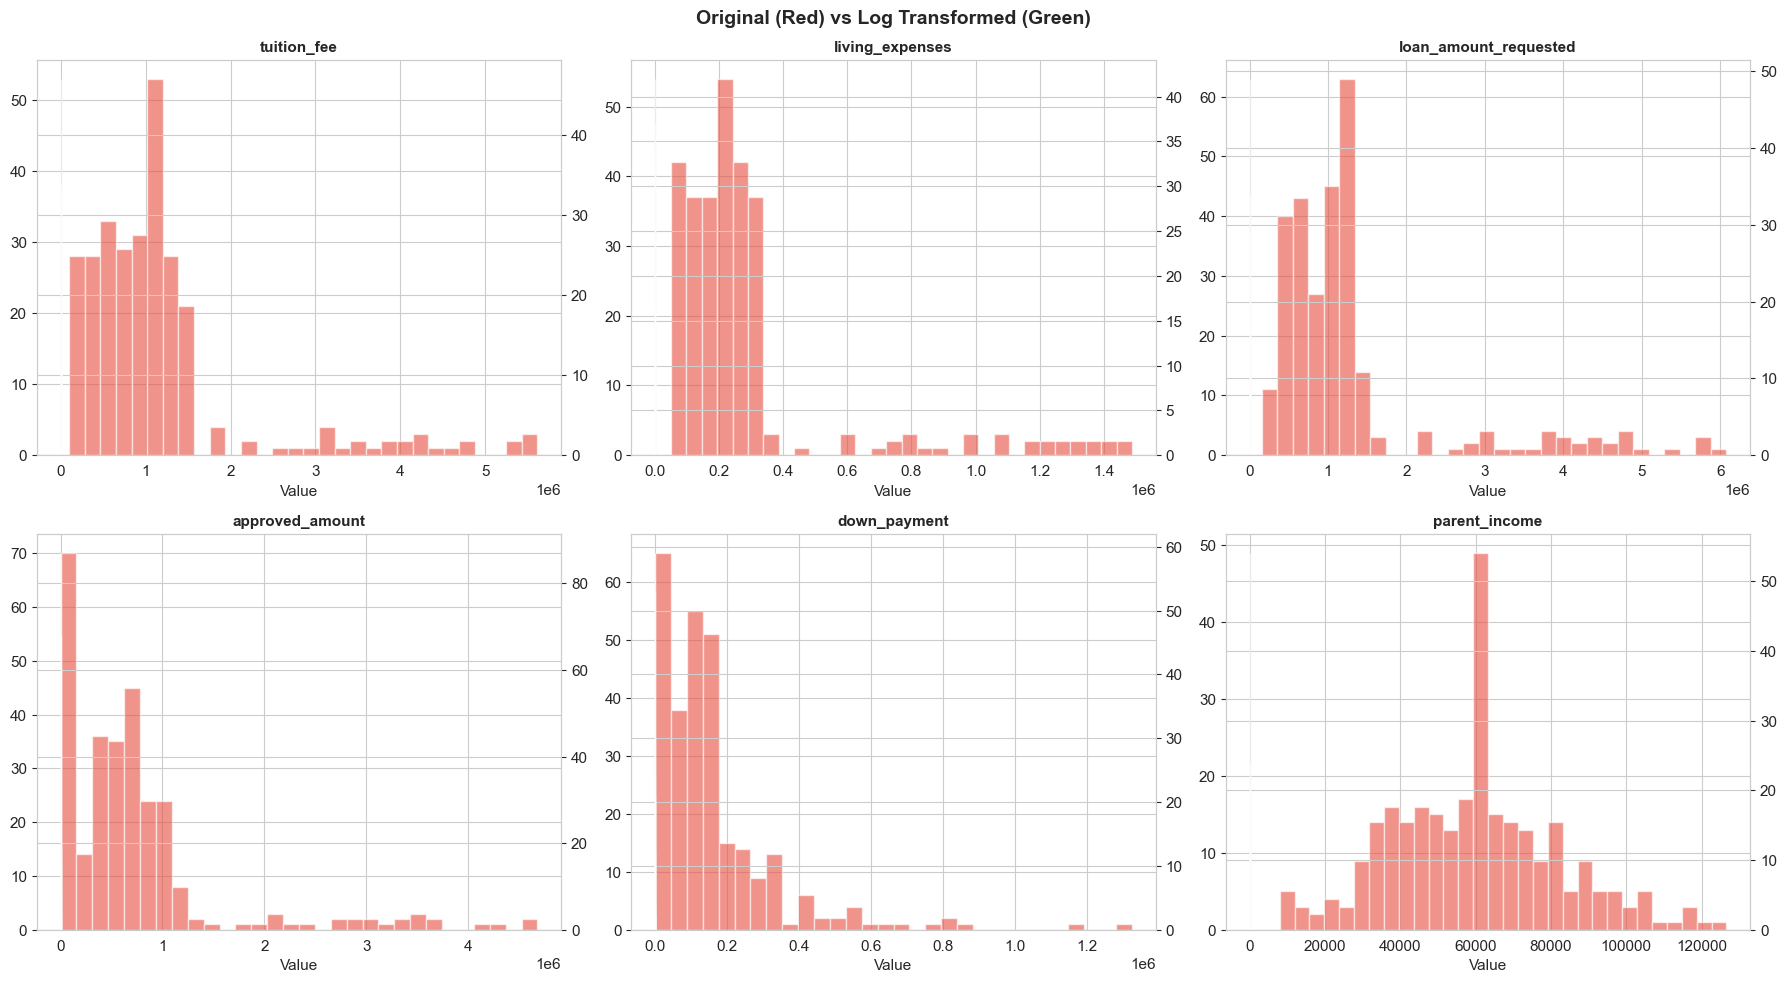

In [ ]:
# before vs after log transform — compare karo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(log_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#E74C3C', alpha=0.6, label='Original')
    ax2 = axes[i].twinx()
    ax2.hist(df[f'log_{col}'].dropna(), bins=30, color='#2ECC71', alpha=0.6, label='Log Transformed')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')

plt.suptitle('Original (Red) vs Log Transformed (Green)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 Encoding — Categorical to Numerical

In [ ]:
# Ordinal Encoding — jahan order matter karta hai

# course_level: Diploma < UG < PG < PhD
course_order = ['Diploma', 'UG', 'PG', 'PhD']
df['course_level_enc'] = df['course_level'].map({v: i for i, v in enumerate(course_order)})
print('course_level_enc mapping:', {v: i for i, v in enumerate(course_order)})

# institute_tier: Tier3 < Tier2 < Tier1 < ForeignOther < ForeignTop
tier_order = ['Tier3','Tier2','Tier1','ForeignOther','ForeignTop']
df['institute_tier_enc'] = df['institute_tier'].map({v: i for i, v in enumerate(tier_order)})
print('institute_tier_enc mapping:', {v: i for i, v in enumerate(tier_order)})

course_level_enc mapping: {'Diploma': 0, 'UG': 1, 'PG': 2, 'PhD': 3}
institute_tier_enc mapping: {'Tier3': 0, 'Tier2': 1, 'Tier1': 2, 'ForeignOther': 3, 'ForeignTop': 4}


In [ ]:
# One-Hot Encoding — course_stream aur country (no order)
df = pd.get_dummies(df, columns=['course_stream','country'], drop_first=True, dtype=int)

print(f'Shape after encoding: {df.shape}')
print('\nNew dummy columns:', [c for c in df.columns if 'course_stream' in c or 'country' in c])

Shape after encoding: (284, 35)

New dummy columns: ['course_stream_Engineering', 'course_stream_Law', 'course_stream_Management', 'course_stream_Medical', 'course_stream_Other', 'country_Canad', 'country_India', 'country_UK', 'country_USA']


In [ ]:
# Original categorical columns drop karo (unencoded versions)
df.drop(columns=['course_level','institute_tier'], inplace=True)
print(f'Shape after dropping originals: {df.shape}')

Shape after dropping originals: (284, 33)


In [ ]:
# final cleaned dataset ka preview
print(f'Cleaned Dataset Shape : {df.shape}')
df.head(3)

Cleaned Dataset Shape : (284, 33)


,age,academic_score,entrance_score,parent_income,parent_existing_emi,parent_dti,parent_cibil,tuition_fee,living_expenses,down_payment,...,institute_tier_enc,course_stream_Engineering,course_stream_Law,course_stream_Management,course_stream_Medical,course_stream_Other,country_Canad,country_India,country_UK,country_USA
0,23.000000,75.35,405.000000,14940.0,3104.0,0.208000,748.0,583269.0,176765.0,23703.0,...,0,0,1,0,0,0,0,1,0,0
1,24.963768,83.52,590.000000,43837.0,3593.0,0.082000,771.0,1384480.0,96980.0,96142.0,...,1,0,1,0,0,0,0,1,0,0
2,24.963768,71.49,552.373188,8000.0,2809.0,0.200417,830.0,506706.0,69243.0,132008.0,...,1,0,0,0,0,1,0,1,0,0


---
# Feature Engineering

In [ ]:
# naye meaningful features banao

# 1. Loan to Income Ratio — income ke comparison mein kitna loan maanga
df['loan_to_income_ratio'] = df['loan_amount_requested'] / (df['parent_income'] + 1)

# 2. Total Education Cost — tuition + living expenses
df['total_cost'] = df['tuition_fee'] + df['living_expenses']

# 3. Net Loan Needed — down payment ke baad kitna bacha
df['net_loan_needed'] = df['total_cost'] - df['down_payment']

# 4. Fee Coverage Ratio — loan kitna cost cover kar raha hai
df['fee_coverage_ratio'] = df['loan_amount_requested'] / (df['total_cost'] + 1)

# 5. Estimated Monthly EMI
df['est_monthly_emi'] = df['loan_amount_requested'] / (df['tenure_years'] * 12 + 1)

# 6. Total Debt Burden — existing EMI + new EMI as fraction of income
df['total_debt_burden'] = (df['parent_existing_emi'] + df['est_monthly_emi']) / (df['parent_income'] + 1)

# 7. Is Foreign Study — binary flag
foreign_cols = [c for c in df.columns if 'country_' in c]
df['is_foreign_study'] = df[foreign_cols].any(axis=1).astype(int)

# 8. Is Top Institute — Tier1 ya ForeignTop
# institute_tier_enc: Tier1=2, ForeignOther=3, ForeignTop=4
df['is_top_institute'] = (df['institute_tier_enc'] >= 2).astype(int)

# 9. Academic to Entrance Score ratio (normalized)
df['score_combined'] = (df['academic_score'] / 100) + (df['entrance_score'] / 800)

print('Naye Feature Engineering columns banaye gaye:')
new_feats = ['loan_to_income_ratio','total_cost','net_loan_needed',
             'fee_coverage_ratio','est_monthly_emi','total_debt_burden',
             'is_foreign_study','is_top_institute','score_combined']
for f in new_feats:
    print(f'  ✓ {f}')
print(f'\nFinal Dataset Shape: {df.shape}')

Naye Feature Engineering columns banaye gaye:
  ✓ loan_to_income_ratio
  ✓ total_cost
  ✓ net_loan_needed
  ✓ fee_coverage_ratio
  ✓ est_monthly_emi
  ✓ total_debt_burden
  ✓ is_foreign_study
  ✓ is_top_institute
  ✓ score_combined

Final Dataset Shape: (284, 42)


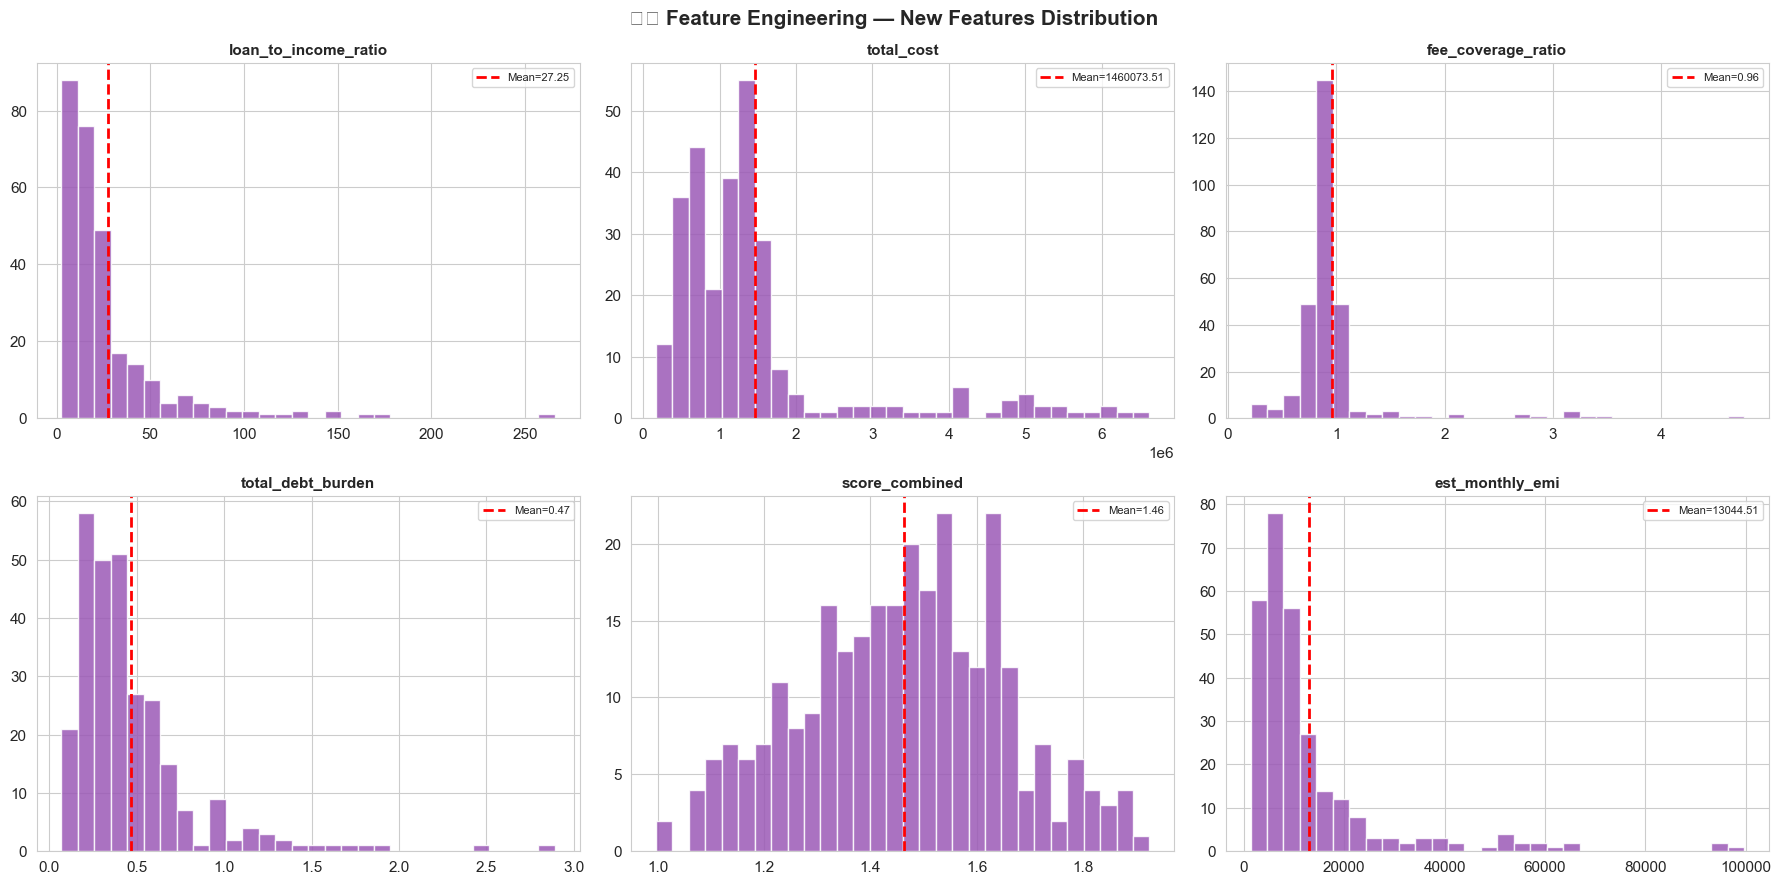

In [ ]:
# naye features ki distribution dekho
fe_plot = ['loan_to_income_ratio','total_cost','fee_coverage_ratio',
           'total_debt_burden','score_combined','est_monthly_emi']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(fe_plot):
    axes[i].hist(df[col].dropna(), bins=30, color='#9B59B6', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', lw=2, linestyle='--',
                    label=f'Mean={df[col].mean():.2f}')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('⚙️ Feature Engineering — New Features Distribution',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# X aur y define karo — Classification ke liye
# approved_amount aur interest_rate = output columns hain, feature mein nahi chahiye

drop_for_clf = ['loan_status','approved_amount','interest_rate',
                'log_approved_amount']  # targets & leakage columns
drop_for_clf = [c for c in drop_for_clf if c in df.columns]

X = df.drop(columns=drop_for_clf)
y = df['loan_status'].astype(int)

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print(f'Class Distribution — 0: {(y==0).sum()}  |  1: {(y==1).sum()}')

X shape: (284, 38)  |  y shape: (284,)
Class Distribution — 0: 81  |  1: 203


In [ ]:
# Class Imbalance handle — Oversampling (manual SMOTE alternative)
# majority = 1 (approved), minority = 0 (rejected)
df_temp = X.copy()
df_temp['loan_status'] = y.values

df_majority = df_temp[df_temp['loan_status'] == 1]
df_minority = df_temp[df_temp['loan_status'] == 0]

# minority class oversample karo
df_minority_up = resample(df_minority,
                           replace=True,
                           n_samples=len(df_majority),
                           random_state=42)

df_balanced = pd.concat([df_majority, df_minority_up])

X_bal = df_balanced.drop(columns=['loan_status'])
y_bal = df_balanced['loan_status'].astype(int)

print(f'Before balancing — 0: {(y==0).sum()}  |  1: {(y==1).sum()}')
print(f'After  balancing — 0: {(y_bal==0).sum()}  |  1: {(y_bal==1).sum()}')

Before balancing — 0: 81  |  1: 203
After  balancing — 0: 203  |  1: 203


In [ ]:
# Train-Test Split — Classification
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

print(f'Train size : {X_train.shape[0]}')
print(f'Test  size : {X_test.shape[0]}')

Train size : 324
Test  size : 82


In [ ]:
# Feature Scaling — StandardScaler (Classification)
scaler_clf = StandardScaler()
X_train_sc = scaler_clf.fit_transform(X_train)
X_test_sc  = scaler_clf.transform(X_test)

print('Features scaled (StandardScaler)')
print(f'   Mean ~ 0 : {X_train_sc.mean():.4f}')
print(f'   Std  ~ 1 : {X_train_sc.std():.4f}')

Features scaled (StandardScaler)
   Mean ~ 0 : -0.0000
   Std  ~ 1 : 1.0000


--- 
# CLASSIFICATION
## Target: `loan_status` (0 = Rejected, 1 = Approved)

### 5.1 Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:,1]

print('Logistic Regression Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_lr):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_lr):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_lr):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'\n{classification_report(y_test, y_pred_lr)}')

Logistic Regression Results:
  Accuracy  : 0.6463
  Precision : 0.6500
  Recall    : 0.6341
  F1 Score  : 0.6420
  ROC-AUC   : 0.7412

              precision    recall  f1-score   support

           0       0.64      0.66      0.65        41
           1       0.65      0.63      0.64        41

    accuracy                           0.65        82
   macro avg       0.65      0.65      0.65        82
weighted avg       0.65      0.65      0.65        82



### 5.2 Decision Tree

In [ ]:
dt = DecisionTreeClassifier(max_depth=7, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)  # tree ko scaling ki zaroorat nahi

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print('Decision Tree Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_dt):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_dt):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_dt):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_dt):.4f}')

Decision Tree Results:
  Accuracy  : 0.8415
  Precision : 0.8500
  Recall    : 0.8293
  F1 Score  : 0.8395
  ROC-AUC   : 0.8650


### 5.3 Random Forest

In [ ]:
# Random Forest — ensemble method, handles overfitting
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print('Random Forest Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_rf):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_rf):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_rf):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_rf):.4f}')

Random Forest Results:
  Accuracy  : 0.8902
  Precision : 0.8810
  Recall    : 0.9024
  F1 Score  : 0.8916
  ROC-AUC   : 0.9137


### 5.4 Gradient Boosting

In [ ]:
# Gradient Boosting — boosting ensemble, typically best accuracy
gb = GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                 learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

print('Gradient Boosting Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_gb):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_gb):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_gb):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_gb):.4f}')

Gradient Boosting Results:
  Accuracy  : 0.8902
  Precision : 0.8636
  Recall    : 0.9268
  F1 Score  : 0.8941
  ROC-AUC   : 0.9280


### 5.5 SVM

In [ ]:
# SVM — support vector machine, good for small datasets
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42, class_weight='balanced')
svm.fit(X_train_sc, y_train)

y_pred_svm = svm.predict(X_test_sc)
y_prob_svm = svm.predict_proba(X_test_sc)[:,1]

print('SVM Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_svm):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_svm):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_svm):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_svm):.4f}')

SVM Results:
  Accuracy  : 0.7683
  Precision : 0.7500
  Recall    : 0.8049
  F1 Score  : 0.7765
  ROC-AUC   : 0.8459


### 5.6 KNN

In [ ]:
# KNN — K nearest neighbors, distance-based
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)
knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict(X_test_sc)
y_prob_knn = knn.predict_proba(X_test_sc)[:,1]

print('KNN Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_knn):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_knn):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_knn):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_knn):.4f}')

KNN Results:
  Accuracy  : 0.7317
  Precision : 0.7568
  Recall    : 0.6829
  F1 Score  : 0.7179
  ROC-AUC   : 0.7615


### 5.7 Naive Bayes

In [ ]:
# Gaussian Naive Bayes — probabilistic, fast
gnb = GaussianNB()
gnb.fit(X_train_sc, y_train)

y_pred_gnb = gnb.predict(X_test_sc)
y_prob_gnb = gnb.predict_proba(X_test_sc)[:,1]

print('Naive Bayes Results:')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_gnb):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_gnb):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_gnb):.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_gnb):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_gnb):.4f}')

Naive Bayes Results:
  Accuracy  : 0.4756
  Precision : 0.2500
  Recall    : 0.0244
  F1 Score  : 0.0444
  ROC-AUC   : 0.6014


### 5.8 Confusion Matrices — Sabhi Models

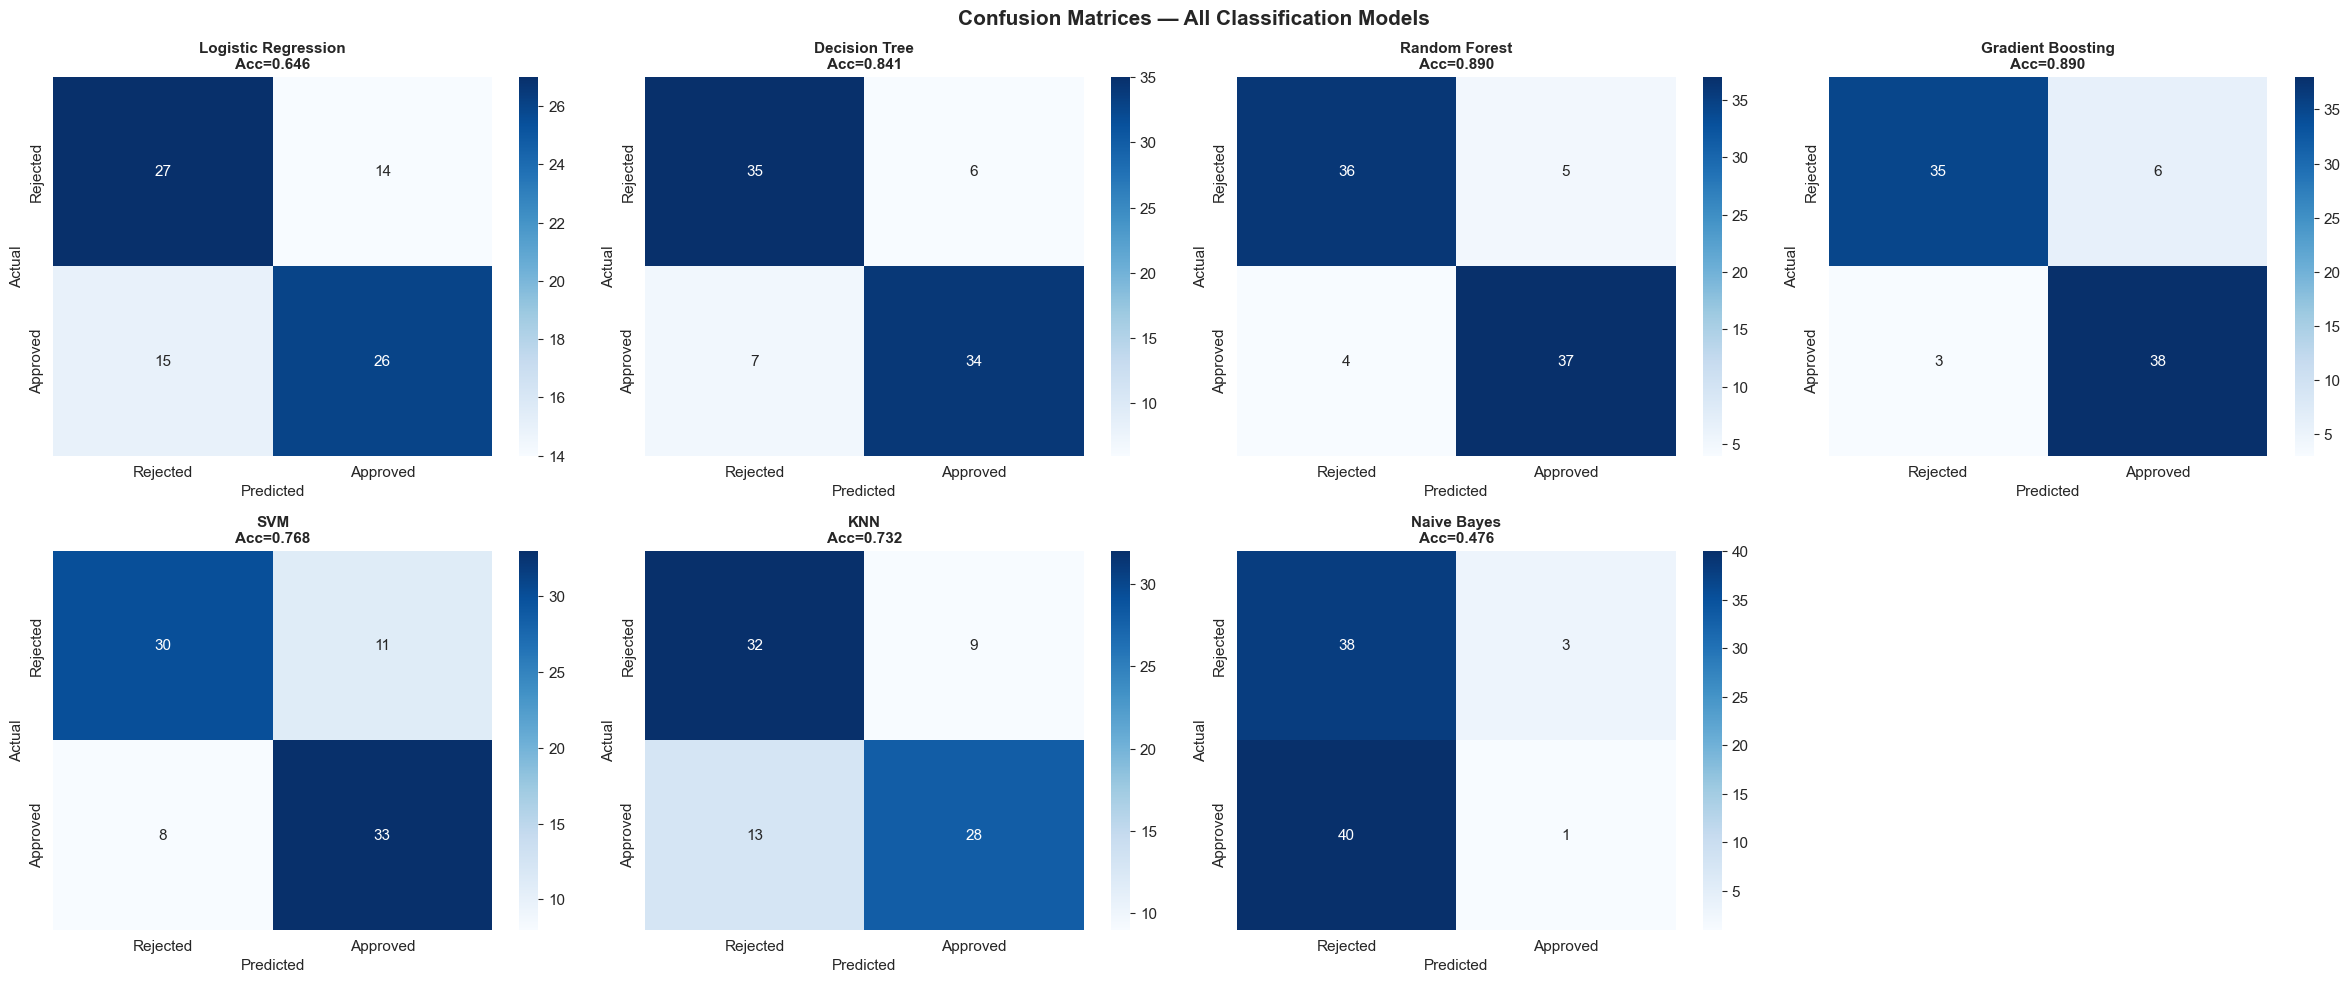

In [ ]:
# confusion matrix — sabhi models ek saath
clf_results = {
    'Logistic Regression' : y_pred_lr,
    'Decision Tree'       : y_pred_dt,
    'Random Forest'       : y_pred_rf,
    'Gradient Boosting'   : y_pred_gb,
    'SVM'                 : y_pred_svm,
    'KNN'                 : y_pred_knn,
    'Naive Bayes'         : y_pred_gnb,
}

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

for i, (name, pred) in enumerate(clf_results.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Rejected','Approved'],
                yticklabels=['Rejected','Approved'])
    acc = accuracy_score(y_test, pred)
    axes[i].set_title(f'{name}\nAcc={acc:.3f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Classification Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.9 ROC Curves — Sabhi Models

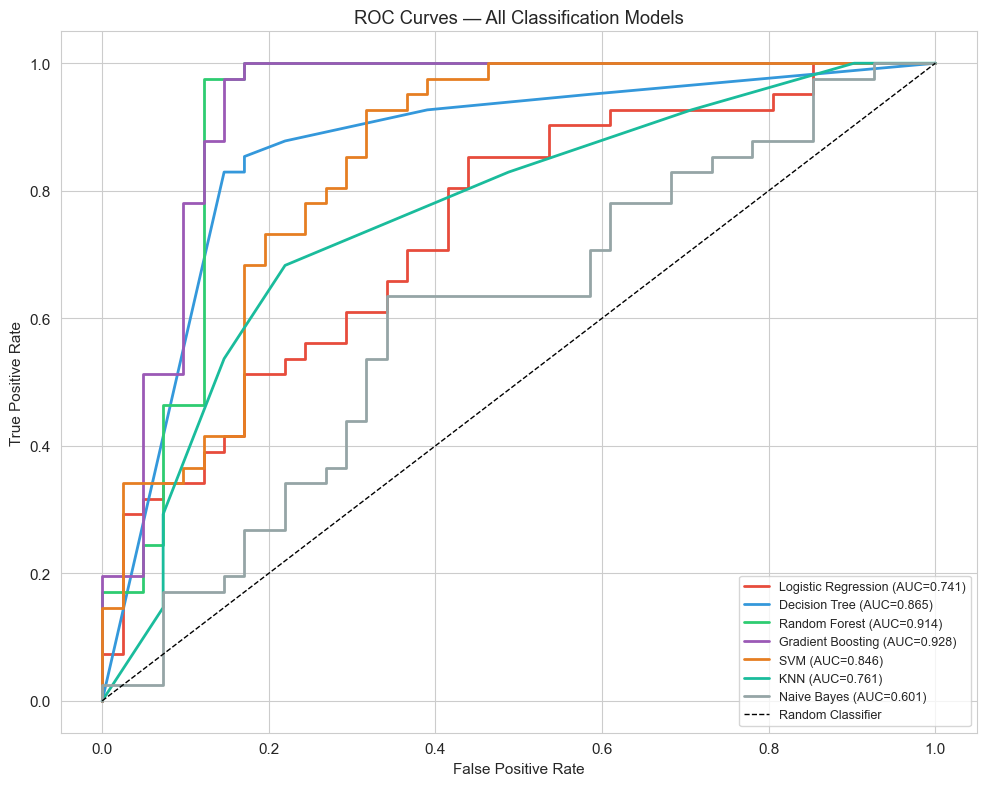

In [ ]:
# ROC curves – acha model curve upper-left corner ke paas hoga
clf_probs = {
    'Logistic Regression' : y_prob_lr,
    'Decision Tree'       : y_prob_dt,
    'Random Forest'       : y_prob_rf,
    'Gradient Boosting'   : y_prob_gb,
    'SVM'                 : y_prob_svm,
    'KNN'                 : y_prob_knn,
    'Naive Bayes'         : y_prob_gnb,
}

plt.figure(figsize=(10, 8))
colors_roc = ['#E74C3C','#3498DB','#2ECC71','#9B59B6','#E67E22','#1ABC9C','#95A5A6']

for (name, prob), color in zip(clf_probs.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val     = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Classification Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.10 Feature Importance — Random Forest

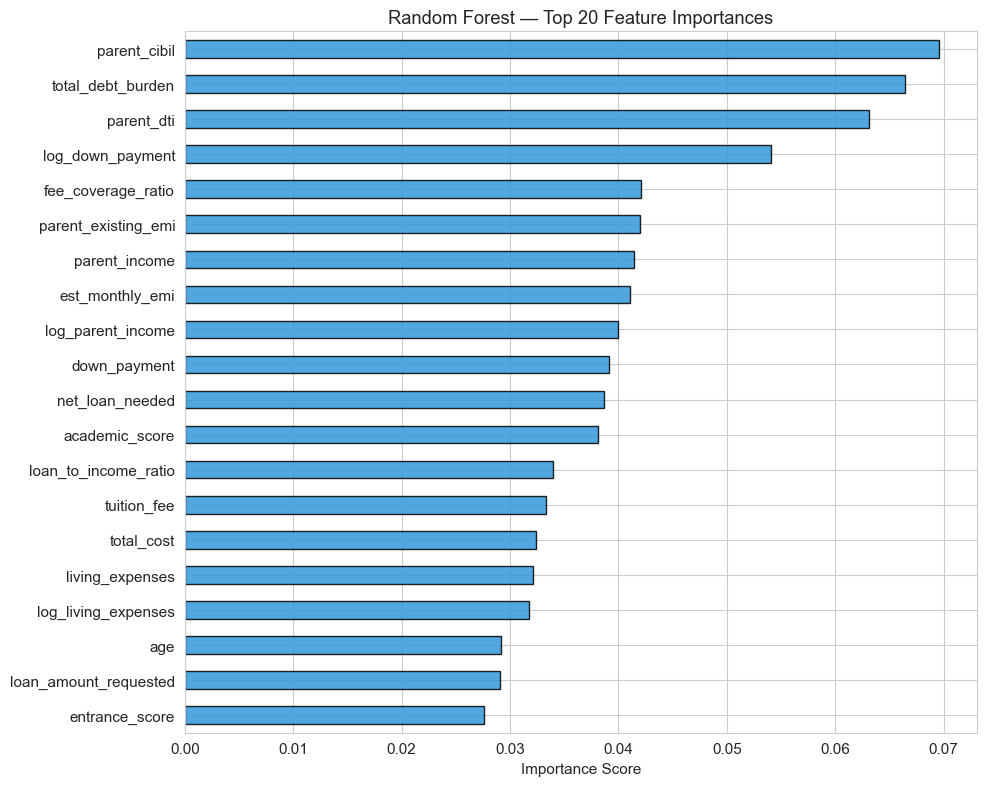

Top 10 Features:
parent_cibil           0.069589
total_debt_burden      0.066422
parent_dti             0.063124
log_down_payment       0.054091
fee_coverage_ratio     0.042071
parent_existing_emi    0.042025
parent_income          0.041384
est_monthly_emi        0.041065
log_parent_income      0.039928
down_payment           0.039112


In [ ]:
# Random Forest feature importance — kaunsa feature sabse important hai
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(20)  # top 20

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='#3498DB', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 Features:')
print(feat_imp.tail(10)[::-1].to_string())

### 5.11 Hyperparameter Tuning — Best Model (Random Forest)

In [ ]:
# GridSearchCV se best parameters dhundho
param_grid_rf = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_split' : [2, 5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
grid_rf.fit(X_train, y_train)

print(f' Best Parameters : {grid_rf.best_params_}')
print(f'   Best CV F1 Score: {grid_rf.best_score_:.4f}')

# best model se predict karo
best_rf  = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print(f'\nTest F1 Score (Tuned RF): {f1_score(y_test, y_pred_best_rf):.4f}')

 Best Parameters : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
   Best CV F1 Score: 0.8671

Test F1 Score (Tuned RF): 0.9176


### 5.12 Cross Validation — All Models

In [ ]:
# 5-Fold Cross Validation
cv_models = {
    'Logistic Regression': (lr, X_train_sc, y_train),
    'Decision Tree'      : (dt, X_train,    y_train),
    'Random Forest'      : (rf, X_train,    y_train),
    'Gradient Boosting'  : (gb, X_train,    y_train),
    'KNN'                : (knn, X_train_sc, y_train),
    'Naive Bayes'        : (gnb, X_train_sc, y_train),
}

print('5-Fold Cross Validation — F1 Score:\n')
cv_results = {}
for name, (model, Xtr, ytr) in cv_models.items():
    scores = cross_val_score(model, Xtr, ytr, cv=5, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<25} | Mean={scores.mean():.4f} | Std={scores.std():.4f} | {[round(s,3) for s in scores]}')

5-Fold Cross Validation — F1 Score:



  Logistic Regression       | Mean=0.6504 | Std=0.0082 | [np.float64(0.646), np.float64(0.644), np.float64(0.648), np.float64(0.647), np.float64(0.667)]
  Decision Tree             | Mean=0.7856 | Std=0.0935 | [np.float64(0.604), np.float64(0.806), np.float64(0.871), np.float64(0.82), np.float64(0.828)]
  Random Forest             | Mean=0.8557 | Std=0.0588 | [np.float64(0.741), np.float64(0.899), np.float64(0.889), np.float64(0.862), np.float64(0.889)]
  Gradient Boosting         | Mean=0.8646 | Std=0.0450 | [np.float64(0.786), np.float64(0.899), np.float64(0.906), np.float64(0.844), np.float64(0.889)]
  KNN                       | Mean=0.6509 | Std=0.0617 | [np.float64(0.623), np.float64(0.712), np.float64(0.596), np.float64(0.586), np.float64(0.737)]
  Naive Bayes               | Mean=0.1364 | Std=0.0605 | [np.float64(0.056), np.float64(0.108), np.float64(0.233), np.float64(0.171), np.float64(0.114)]


---
# REGRESSION
## Target: `approved_amount` (Kitna loan actually milega — ₹)

In [ ]:
# Sirf approved loans pe train karenge (rejected ka amount = 0, uspe regression nahi karna)
df_reg = df[df['loan_status'] == 1].copy()
print(f'Approved loans (for regression): {len(df_reg)} rows')

# Target — log transform kyunki approved_amount skewed hai
df_reg['target_log_amount'] = np.log1p(df_reg['approved_amount'])

# Features aur Target define karo
drop_reg = ['loan_status','approved_amount','interest_rate',
            'log_approved_amount','target_log_amount']
drop_reg = [c for c in drop_reg if c in df_reg.columns]

X_reg = df_reg.drop(columns=drop_reg)
y_reg = df_reg['target_log_amount']

print(f'X_reg shape: {X_reg.shape}  |  y_reg shape: {y_reg.shape}')

Approved loans (for regression): 203 rows
X_reg shape: (203, 38)  |  y_reg shape: (203,)


In [ ]:
# Train-Test Split — Regression
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scaling
scaler_reg = StandardScaler()
X_reg_tr_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_te_sc = scaler_reg.transform(X_reg_test)

print(f'Train: {X_reg_train.shape}  |  Test: {X_reg_test.shape}')

Train: (162, 38)  |  Test: (41, 38)


In [ ]:
# Helper function — metrics calculate karo aur actual scale mein dikho
def reg_metrics(name, y_true, y_pred_log):
    # reverse log transform
    y_true_act = np.expm1(y_true)
    y_pred_act = np.expm1(y_pred_log)
    
    mae  = mean_absolute_error(y_true_act, y_pred_act)
    rmse = np.sqrt(mean_squared_error(y_true_act, y_pred_act))
    r2   = r2_score(y_true_act, y_pred_act)
    
    print(f'\n  {name}')
    print(f'    MAE   : {mae:,.0f}')
    print(f'    RMSE  : {rmse:,.0f}')
    print(f'    R²    : {r2:.4f}')
    return {'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'R²': round(r2,4)}

### 6.1 Linear Regression

In [ ]:
reg_metrics_list = []

# Linear Regression — baseline
lin_reg = LinearRegression()
lin_reg.fit(X_reg_tr_sc, y_reg_train)
y_pred_lin = lin_reg.predict(X_reg_te_sc)
reg_metrics_list.append(reg_metrics('Linear Regression', y_reg_test, y_pred_lin))


  Linear Regression
    MAE   : 210,658
    RMSE  : 408,708
    R²    : 0.4735


### 6.2 Ridge Regression

In [ ]:
# Ridge — L2 regularization (overfitting kam karta hai)
ridge = Ridge(alpha=1.0)
ridge.fit(X_reg_tr_sc, y_reg_train)
y_pred_ridge = ridge.predict(X_reg_te_sc)
reg_metrics_list.append(reg_metrics('Ridge Regression', y_reg_test, y_pred_ridge))


  Ridge Regression
    MAE   : 226,031
    RMSE  : 445,647
    R²    : 0.3740


### 6.3 Lasso Regression

In [ ]:
# Lasso — L1 regularization (feature selection bhi karta hai)
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_reg_tr_sc, y_reg_train)
y_pred_lasso = lasso.predict(X_reg_te_sc)
reg_metrics_list.append(reg_metrics('Lasso Regression', y_reg_test, y_pred_lasso))

# zero ho gaye features dekhna
zero_coefs = (lasso.coef_ == 0).sum()
print(f'  Features zeroed out by Lasso: {zero_coefs}/{len(lasso.coef_)}')


  Lasso Regression
    MAE   : 204,001
    RMSE  : 425,317
    R²    : 0.4298
  Features zeroed out by Lasso: 16/38


### 6.4 ElasticNet

In [ ]:
# ElasticNet — Ridge + Lasso ka combination
en = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000)
en.fit(X_reg_tr_sc, y_reg_train)
y_pred_en = en.predict(X_reg_te_sc)
reg_metrics_list.append(reg_metrics('ElasticNet', y_reg_test, y_pred_en))


  ElasticNet
    MAE   : 219,653
    RMSE  : 459,506
    R²    : 0.3345


### 6.5 Decision Tree Regressor

In [ ]:
# Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=7, random_state=42)
dt_reg.fit(X_reg_train, y_reg_train)
y_pred_dt_reg = dt_reg.predict(X_reg_test)
reg_metrics_list.append(reg_metrics('Decision Tree Regressor', y_reg_test, y_pred_dt_reg))


  Decision Tree Regressor
    MAE   : 160,086
    RMSE  : 232,902
    R²    : 0.8290


### 6.6 Random Forest Regressor

In [ ]:
# Random Forest Regressor — robust, handles non-linearity
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_reg_train, y_reg_train)
y_pred_rf_reg = rf_reg.predict(X_reg_test)
reg_metrics_list.append(reg_metrics('Random Forest Regressor', y_reg_test, y_pred_rf_reg))


  Random Forest Regressor
    MAE   : 185,775
    RMSE  : 358,772
    R²    : 0.5943


### 6.7 Gradient Boosting Regressor

In [ ]:
# Gradient Boosting Regressor — usually best accuracy
gb_reg = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                    learning_rate=0.05, random_state=42)
gb_reg.fit(X_reg_train, y_reg_train)
y_pred_gb_reg = gb_reg.predict(X_reg_test)
reg_metrics_list.append(reg_metrics('Gradient Boosting Regressor', y_reg_test, y_pred_gb_reg))


  Gradient Boosting Regressor
    MAE   : 168,918
    RMSE  : 364,438
    R²    : 0.5814


### 6.8 Residual Analysis — Best Regression Model

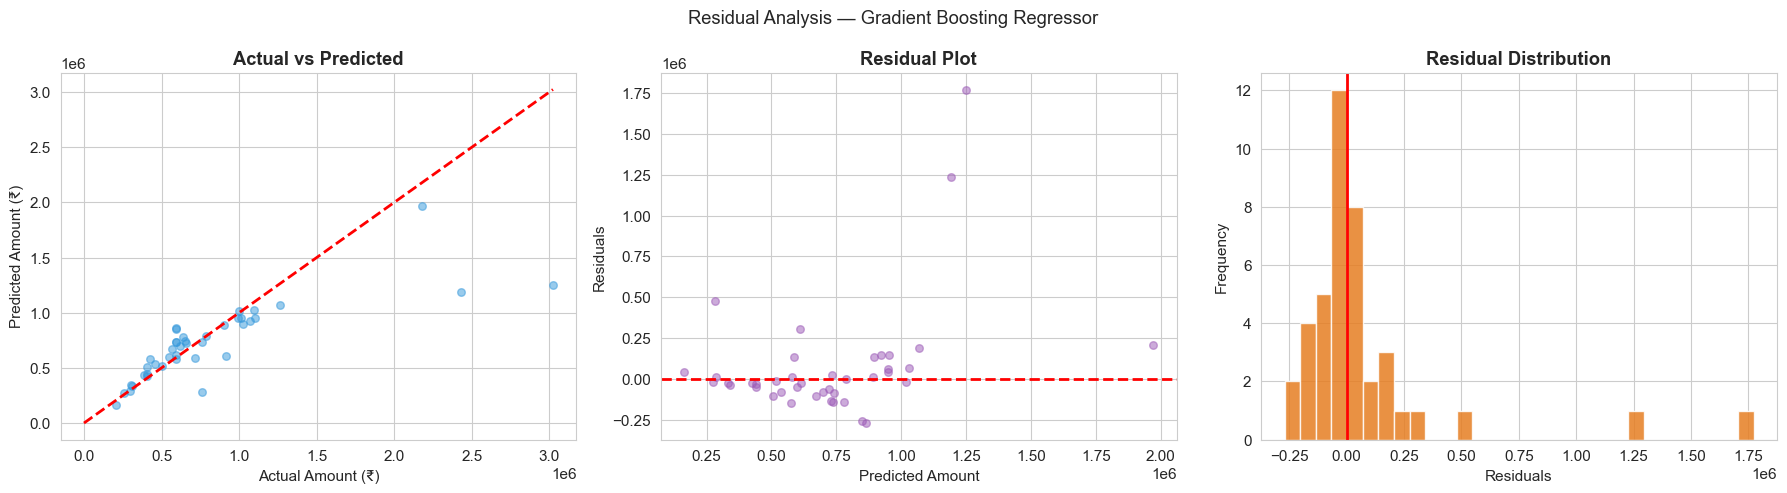

In [ ]:
# best model ka residual analysis
# residuals = actual - predicted (actual ₹ scale mein)
y_actual_amt   = np.expm1(y_reg_test.values)
y_pred_amt     = np.expm1(gb_reg.predict(X_reg_test))
residuals      = y_actual_amt - y_pred_amt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_actual_amt, y_pred_amt, alpha=0.5, color='#3498DB', s=30)
max_v = max(y_actual_amt.max(), y_pred_amt.max())
axes[0].plot([0, max_v], [0, max_v], 'r--', lw=2)
axes[0].set_xlabel('Actual Amount (₹)')
axes[0].set_ylabel('Predicted Amount (₹)')
axes[0].set_title('Actual vs Predicted', fontweight='bold')

# 2. Residual Plot
axes[1].scatter(y_pred_amt, residuals, alpha=0.5, color='#9B59B6', s=30)
axes[1].axhline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted Amount')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

# 3. Residual Distribution
axes[2].hist(residuals, bins=30, color='#E67E22', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', lw=2)
axes[2].set_xlabel('Residuals')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Residual Analysis — Gradient Boosting Regressor')
plt.tight_layout()
plt.show()

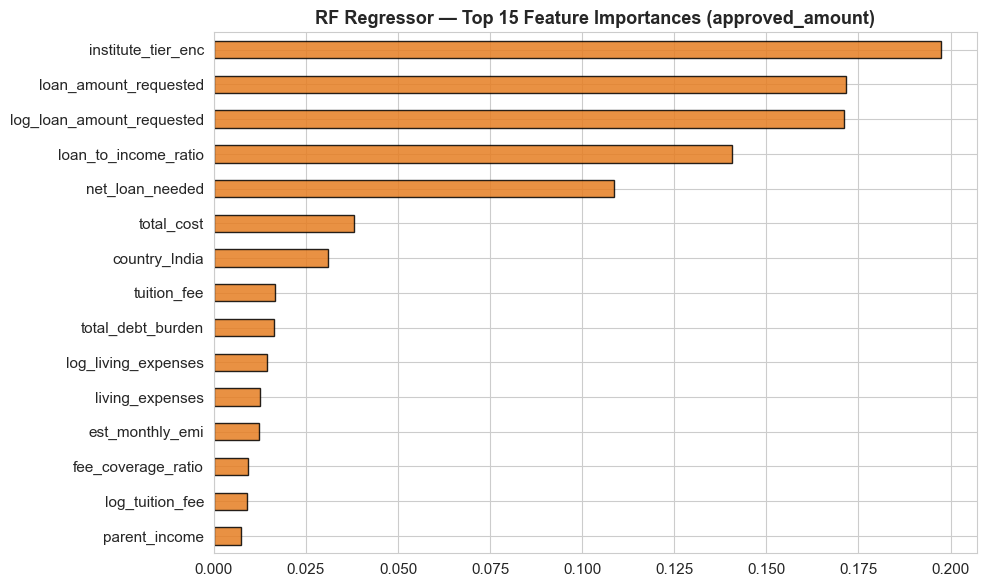

In [ ]:
# Regression feature importance
rf_reg_imp = pd.Series(rf_reg.feature_importances_, index=X_reg_train.columns)
rf_reg_imp = rf_reg_imp.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
rf_reg_imp.plot(kind='barh', color='#E67E22', edgecolor='black', alpha=0.85)
plt.title('RF Regressor — Top 15 Feature Importances (approved_amount)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# CLUSTERING
## Student segments  — Unsupervised Learning

In [ ]:
# Clustering ke liye — target aur outcome columns remove karo
# sirf input features rakhni hain
drop_clust = ['loan_status','approved_amount','interest_rate','log_approved_amount']
drop_clust = [c for c in drop_clust if c in df.columns]

df_clust = df.drop(columns=drop_clust).copy()

# scaling mandatory hai — KMeans distance-based hai
scaler_clust = StandardScaler()
X_clust      = scaler_clust.fit_transform(df_clust)

print(f'Clustering data shape: {X_clust.shape}')

Clustering data shape: (284, 38)


### 7.1 PCA — Dimensionality Reduction

Components for 80% variance: 14
Components for 90% variance: 19


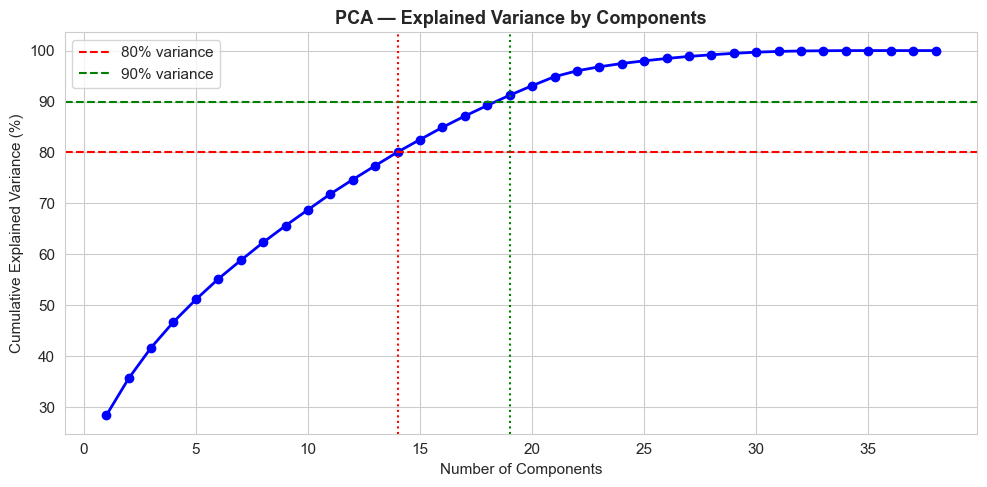

In [ ]:
# PCA — features kam karo for visualization aur speed
pca_full = PCA(random_state=42)
pca_full.fit(X_clust)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)

# kitne components se 80% variance retain hota hai
n_comp_80 = np.argmax(explained_var >= 0.80) + 1
n_comp_90 = np.argmax(explained_var >= 0.90) + 1

print(f'Components for 80% variance: {n_comp_80}')
print(f'Components for 90% variance: {n_comp_90}')

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_var)+1), explained_var*100, 'bo-', lw=2)
plt.axhline(80, color='red',   linestyle='--', label='80% variance')
plt.axhline(90, color='green', linestyle='--', label='90% variance')
plt.axvline(n_comp_80, color='red',   linestyle=':')
plt.axvline(n_comp_90, color='green', linestyle=':')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA — Explained Variance by Components', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 2D PCA — visualization ke liye (2 components)
pca_2d   = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_clust)

# n_comp_80 components wala PCA — model ke liye
pca_nd   = PCA(n_components=min(n_comp_80, X_clust.shape[1]), random_state=42)
X_pca_nd = pca_nd.fit_transform(X_clust)

print(f'2D PCA shape         : {X_pca_2d.shape}')
print(f'Reduced PCA shape    : {X_pca_nd.shape}')
print(f'Variance explained (2D): {pca_2d.explained_variance_ratio_.sum()*100:.2f}%')

2D PCA shape         : (284, 2)
Reduced PCA shape    : (284, 14)
Variance explained (2D): 35.66%


### 7.2 Optimal K — Elbow Method

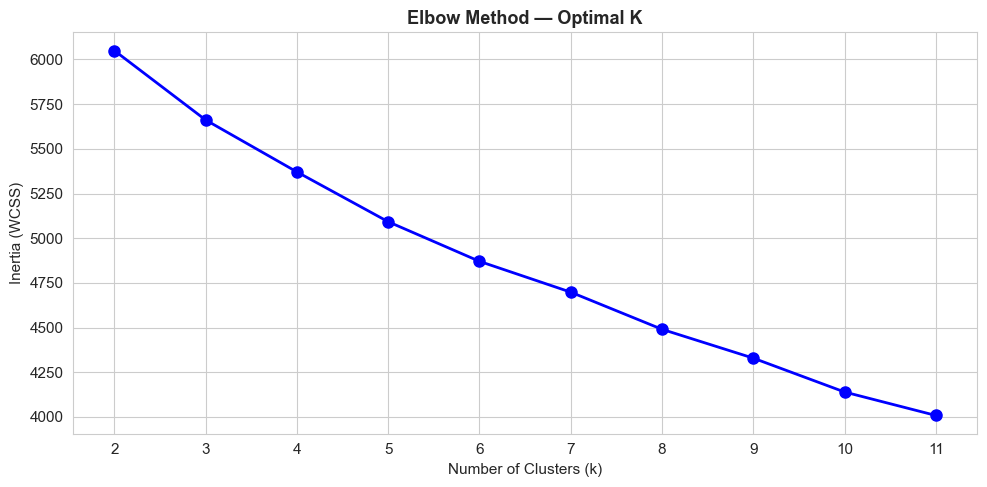

In [ ]:
# Elbow Method — inertia (WCSS) vs k
inertia_vals = []
k_range      = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_nd)
    inertia_vals.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia_vals, 'bo-', lw=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

### 7.3 Optimal K — Silhouette Score

Best K (max Silhouette Score) = 2  (score=0.4528)


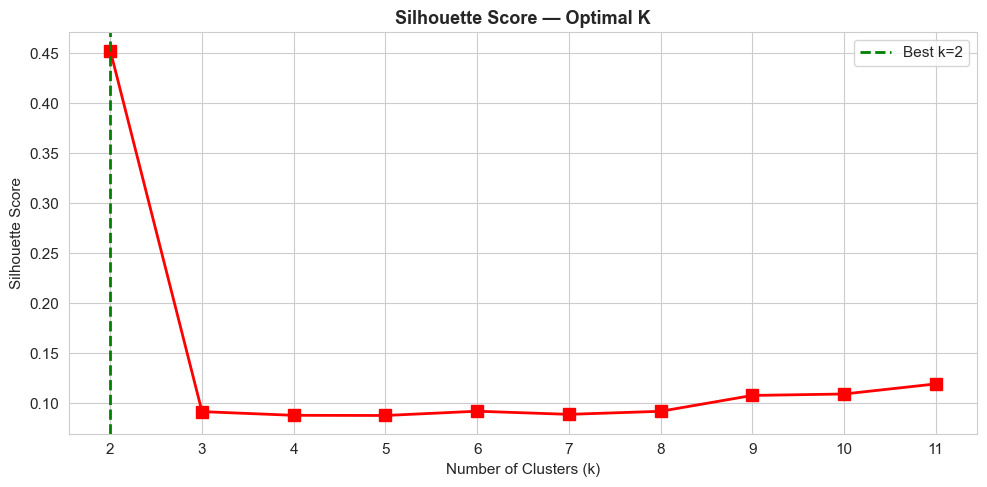

In [ ]:
# Silhouette Score — higher is better (0 to 1)
sil_scores = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pca_nd)
    sil_scores.append(silhouette_score(X_pca_nd, lbl))

best_k = k_range[np.argmax(sil_scores)]
km_sil  = max(sil_scores)   
print(f'Best K (max Silhouette Score) = {best_k}  (score={max(sil_scores):.4f})')

plt.figure(figsize=(10, 5))
plt.plot(k_range, sil_scores, 'rs-', lw=2, markersize=8)
plt.axvline(best_k, color='green', linestyle='--', lw=2, label=f'Best k={best_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Optimal K', fontsize=13, fontweight='bold')
plt.legend()
plt.xticks(k_range)
plt.tight_layout()
plt.show()

### 7.4 K-Means Clustering

In [ ]:
# K-Means with best_k clusters
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clust['kmeans_label'] = kmeans.fit_predict(X_pca_nd)

print(f'K-Means done! k={best_k}')
print(f'Cluster Sizes:')
print(df_clust['kmeans_label'].value_counts().sort_index().to_string())

K-Means done! k=2
Cluster Sizes:
kmeans_label
0    242
1     42


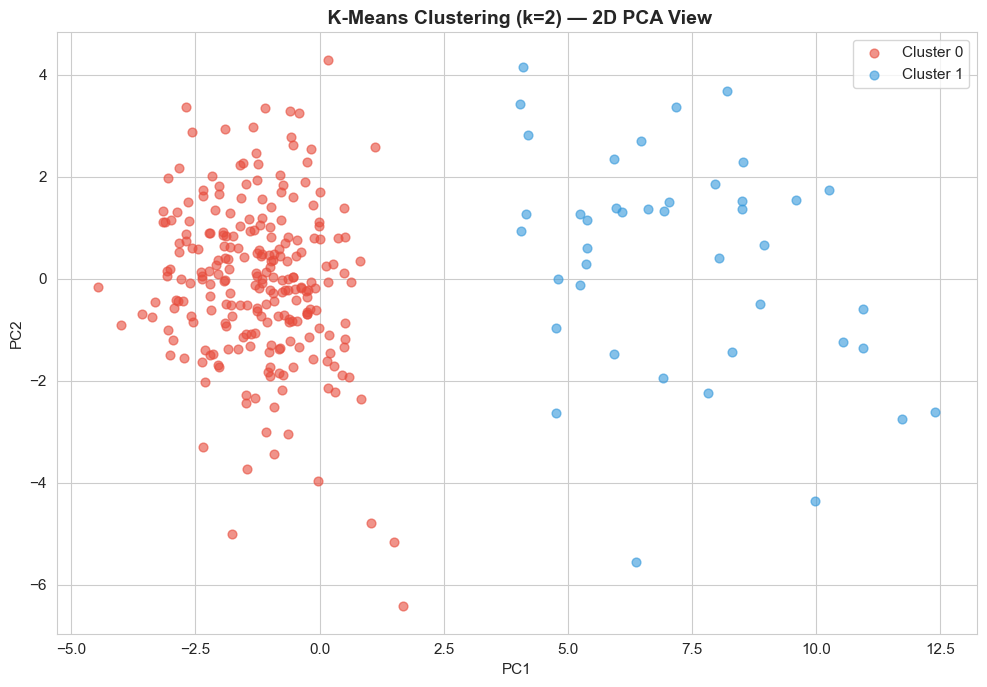

In [ ]:
# K-Means visualization in 2D PCA space
colors_clust = ['#E74C3C','#3498DB','#2ECC71','#9B59B6','#E67E22','#1ABC9C']

plt.figure(figsize=(10, 7))
for label in sorted(df_clust['kmeans_label'].unique()):
    mask = df_clust['kmeans_label'] == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=colors_clust[label], label=f'Cluster {label}',
                alpha=0.6, s=40)

# centroids plot
centroids_2d = pca_2d.transform(pca_nd.inverse_transform(kmeans.cluster_centers_) if hasattr(pca_nd,'inverse_transform') else kmeans.cluster_centers_[:,:2])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f' K-Means Clustering (k={best_k}) — 2D PCA View',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 7.5 DBSCAN Clustering

In [ ]:
# DBSCAN — density based, automatically decides clusters
# -1 label = noise/outlier
dbscan = DBSCAN(eps=1.2, min_samples=5)
db_labels = dbscan.fit_predict(X_pca_nd)
df_clust['dbscan_label'] = db_labels

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()

print(f'DBSCAN done!')
print(f'   Clusters found : {n_clusters_db}')
print(f'   Noise points   : {n_noise} ({round(n_noise/len(db_labels)*100,1)}%)')
print(f'\n   Label distribution:')
print(pd.Series(db_labels).value_counts().sort_index().to_string())

DBSCAN done!
   Clusters found : 0
   Noise points   : 284 (100.0%)

   Label distribution:
-1    284


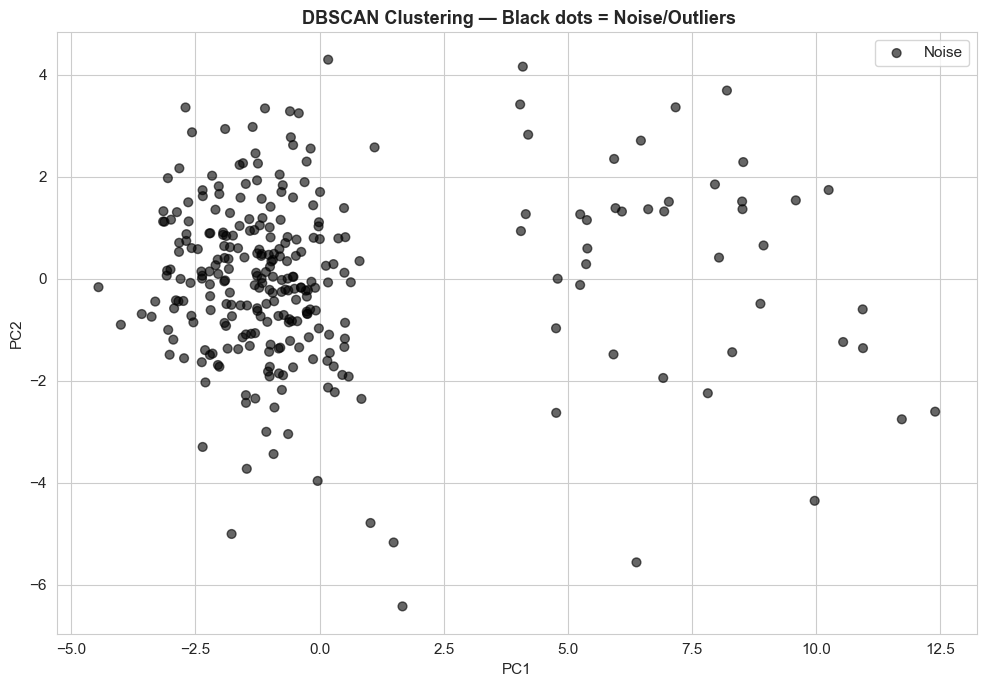

In [ ]:
# DBSCAN visualization
unique_labels = sorted(set(db_labels))
cmap_db = plt.cm.get_cmap('tab10', len(unique_labels))

plt.figure(figsize=(10, 7))
for i, label in enumerate(unique_labels):
    mask  = db_labels == label
    color = 'black' if label == -1 else cmap_db(i)
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=[color]*mask.sum(), label=name, alpha=0.6, s=40)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(' DBSCAN Clustering — Black dots = Noise/Outliers',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 7.6 Hierarchical Clustering

In [ ]:
# # Dendrogram — cut kahan karna hai yeh decide karo
# sample_idx = np.random.choice(len(X_pca_nd), size=min(100, len(X_pca_nd)), replace=False)
# X_sample   = X_pca_nd[sample_idx]

# Z = linkage(X_sample, method='ward')

# plt.figure(figsize=(16, 6))
# dendrogram(Z, truncate_mode='lastp', p=30,
#            leaf_font_size=10, color_threshold=0.7*max(Z[:,2]))
# plt.title('Hierarchical Clustering — Dendrogram (100 samples)',
#           fontsize=13, fontweight='bold')
# plt.xlabel('Sample Index')
# plt.ylabel('Distance')
# plt.tight_layout()
# plt.show()

In [ ]:
# # Agglomerative Clustering — best_k clusters
# agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
# df_clust['hier_label'] = agg.fit_predict(X_pca_nd)

# print(f'Hierarchical Clustering done! k={best_k}')
# print(df_clust['hier_label'].value_counts().sort_index().to_string())

# # visualization
# plt.figure(figsize=(10, 7))
# for label in sorted(df_clust['hier_label'].unique()):
#     mask = df_clust['hier_label'] == label
#     plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
#                 c=[colors_clust[label]]*mask.sum(),
#                 label=f'Cluster {label}', alpha=0.6, s=40)

# plt.xlabel('PC1')
# plt.ylabel('PC2')
# plt.title(f'🌳 Hierarchical Clustering (k={best_k}) — 2D PCA View',
#           fontsize=13, fontweight='bold')
# plt.legend()
# plt.tight_layout()
# plt.show()

### 7.7 Cluster Profiling — Sabse Important Step!

In [ ]:
# original features ke saath cluster labels merge karo
profile_cols = ['age','academic_score','entrance_score',
                'parent_income','parent_cibil','parent_dti',
                'loan_amount_requested','tuition_fee',
                'institute_tier_enc','course_level_enc',
                'is_foreign_study','is_top_institute','loan_to_income_ratio']

profile_cols = [c for c in profile_cols if c in df_clust.columns]

cluster_profile = df_clust.groupby('kmeans_label')[profile_cols].mean().round(2)

print('Cluster Profiles — Mean values per cluster:\n')
cluster_profile.T

Cluster Profiles — Mean values per cluster:



kmeans_label,0,1
age,24.71,25.26
academic_score,77.82,76.03
entrance_score,553.43,530.82
parent_income,59025.85,61441.35
parent_cibil,716.67,714.53
parent_dti,0.20,0.20
loan_amount_requested,902341.62,3687702.66
tuition_fee,831068.39,3132934.07
institute_tier_enc,0.69,3.21
course_level_enc,1.33,1.33


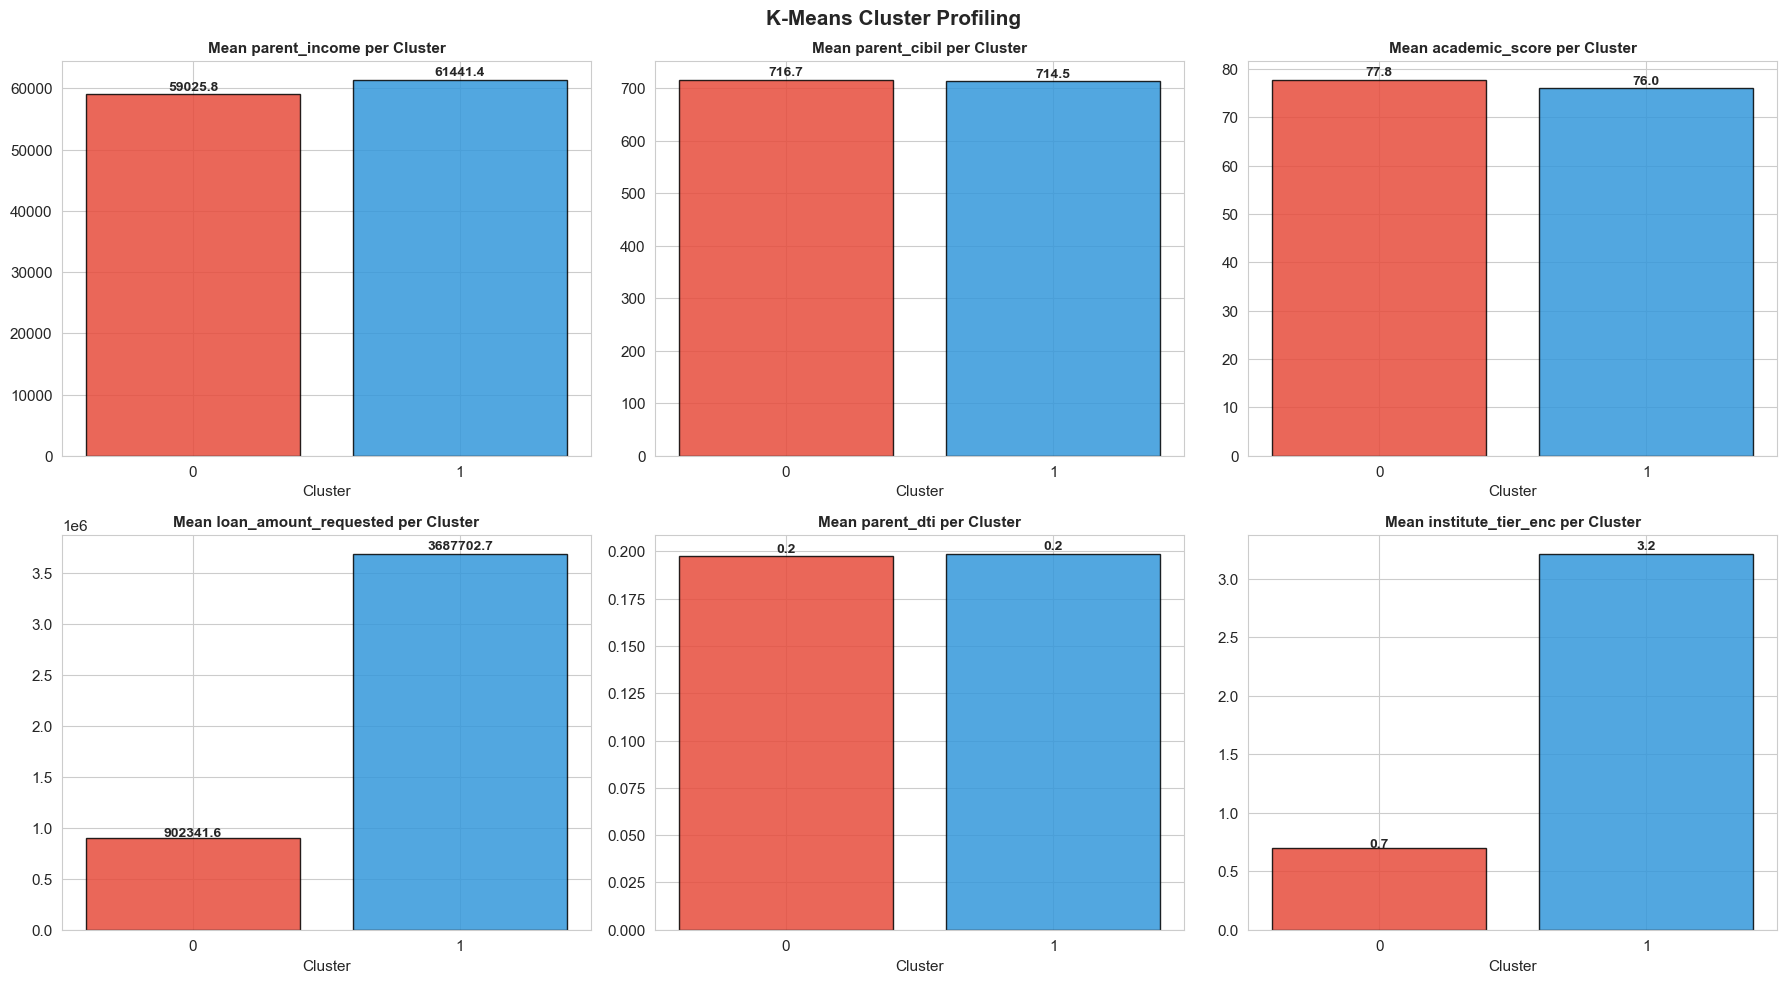

In [ ]:
# Cluster profile — bar plots
top_profile_cols = ['parent_income','parent_cibil','academic_score',
                    'loan_amount_requested','parent_dti','institute_tier_enc']
top_profile_cols = [c for c in top_profile_cols if c in df_clust.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_profile_cols):
    vals = df_clust.groupby('kmeans_label')[col].mean()
    clrs = [colors_clust[j] for j in range(len(vals))]
    bars = axes[i].bar(vals.index.astype(str), vals.values, color=clrs,
                       edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                     f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    axes[i].set_title(f'Mean {col} per Cluster', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster')

plt.suptitle('K-Means Cluster Profiling', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Approval Rate per Cluster:

              Approval Rate  Count  Approval Rate %
kmeans_label                                       
0                  0.743660    242             74.4
1                  0.708231     42             70.8


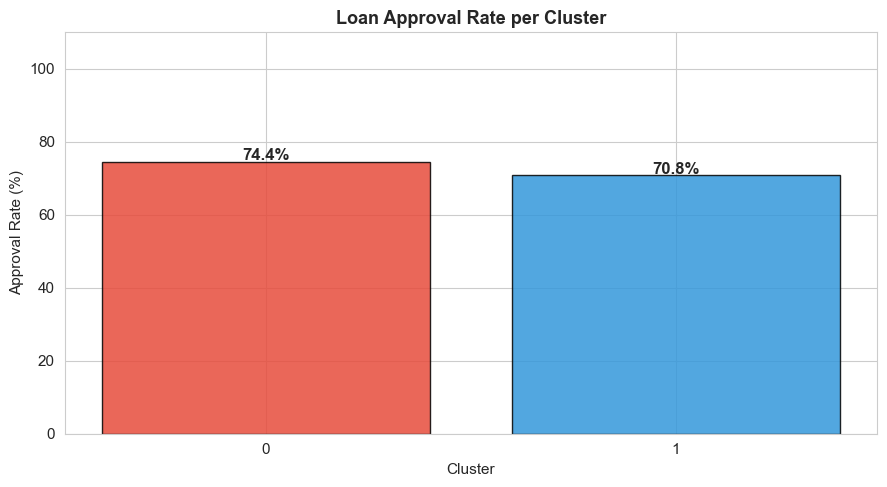

In [ ]:
# Loan Status aur Approval Rate per cluster
df_clust_merged = df_clust.copy()
df_clust_merged['loan_status'] = df['loan_status'].values

cluster_approval = df_clust_merged.groupby('kmeans_label')['loan_status'].agg(['mean','count'])
cluster_approval.columns = ['Approval Rate', 'Count']
cluster_approval['Approval Rate %'] = (cluster_approval['Approval Rate'] * 100).round(1)

print('Approval Rate per Cluster:\n')
print(cluster_approval.to_string())

plt.figure(figsize=(9, 5))
clrs_bar = [colors_clust[i] for i in range(len(cluster_approval))]
bars = plt.bar(cluster_approval.index.astype(str),
               cluster_approval['Approval Rate %'],
               color=clrs_bar, edgecolor='black', alpha=0.85)
for bar, v in zip(bars, cluster_approval['Approval Rate %']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{v}%', ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, 110)
plt.title('Loan Approval Rate per Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Approval Rate (%)')
plt.tight_layout()
plt.show()

---
# Model Evaluation & Comparison

### 8.1 Classification — All Models Comparison

In [ ]:
# sabhi classification models ka comparison table
clf_all = [
    ('Logistic Regression', y_pred_lr,  y_prob_lr,  X_test_sc, y_test),
    ('Decision Tree',       y_pred_dt,  y_prob_dt,  X_test,    y_test),
    ('Random Forest',       y_pred_rf,  y_prob_rf,  X_test,    y_test),
    ('Gradient Boosting',   y_pred_gb,  y_prob_gb,  X_test,    y_test),
    ('SVM',                 y_pred_svm, y_prob_svm, X_test_sc, y_test),
    ('KNN',                 y_pred_knn, y_prob_knn, X_test_sc, y_test),
    ('Naive Bayes',         y_pred_gnb, y_prob_gnb, X_test_sc, y_test),
]

clf_comparison = []
for name, pred, prob, Xte, yte in clf_all:
    clf_comparison.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(yte, pred), 4),
        'Precision' : round(precision_score(yte, pred), 4),
        'Recall'    : round(recall_score(yte, pred), 4),
        'F1 Score'  : round(f1_score(yte, pred), 4),
        'ROC-AUC'   : round(roc_auc_score(yte, prob), 4),
    })

clf_df = pd.DataFrame(clf_comparison).sort_values('F1 Score', ascending=False)
clf_df = clf_df.reset_index(drop=True)

print(' Classification Models Comparison:\n')
clf_df

 Classification Models Comparison:



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8902,0.8636,0.9268,0.8941,0.9280
1,Random Forest,0.8902,0.8810,0.9024,0.8916,0.9137
2,Decision Tree,0.8415,0.8500,0.8293,0.8395,0.8650
3,SVM,0.7683,0.7500,0.8049,0.7765,0.8459
4,KNN,0.7317,0.7568,0.6829,0.7179,0.7615
5,Logistic Regression,0.6463,0.6500,0.6341,0.6420,0.7412
6,Naive Bayes,0.4756,0.2500,0.0244,0.0444,0.6014


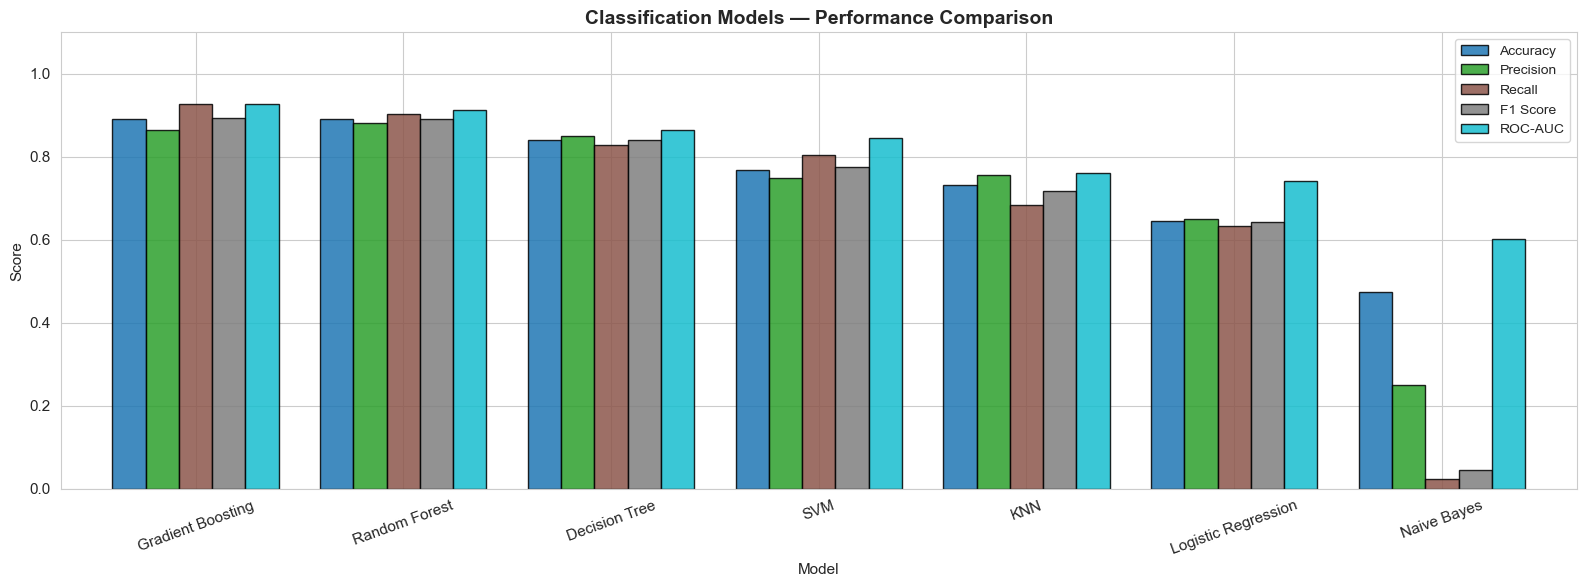

In [ ]:
# comparison bar chart
metrics_to_plot = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']

clf_df_plot = clf_df.set_index('Model')[metrics_to_plot]

clf_df_plot.plot(kind='bar', figsize=(16, 6), colormap='tab10',
                  edgecolor='black', alpha=0.85, width=0.8)
plt.title('Classification Models — Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=20)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

### 8.2 Regression — All Models Comparison

In [ ]:
# regression comparison table
reg_df = pd.DataFrame(reg_metrics_list).sort_values('R²', ascending=False).reset_index(drop=True)

print('Regression Models Comparison:\n')
reg_df

Regression Models Comparison:



,Model,MAE,RMSE,R²
0,Decision Tree Regressor,160085.77,232901.63,0.8290
1,Random Forest Regressor,185775.09,358771.61,0.5943
2,Gradient Boosting Regressor,168918.07,364437.60,0.5814
3,Linear Regression,210657.65,408708.24,0.4735
4,Lasso Regression,204001.25,425317.44,0.4298
5,Ridge Regression,226031.38,445647.50,0.3740
6,ElasticNet,219652.93,459506.18,0.3345


In [ ]:
# # R² bar chart
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# colors_reg = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(reg_df)))

# bars = axes[0].bar(reg_df['Model'], reg_df['R²'], color=colors_reg, edgecolor='black', alpha=0.9)
# for bar, v in zip(bars, reg_df['R²']):
#     axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
#                  f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
# axes[0].set_title('R² Score (Higher = Better)', fontweight='bold')
# axes[0].tick_params(axis='x', rotation=30)
# axes[0].set_ylim(0, 1.1)

# bars2 = axes[1].bar(reg_df['Model'], reg_df['MAPE%'], color='#3498DB', edgecolor='black', alpha=0.85)
# for bar, v in zip(bars2, reg_df['MAPE%']):
#     axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
#                  f'{v}%', ha='center', fontsize=9, fontweight='bold')
# axes[1].set_title('MAPE% (Lower = Better)', fontweight='bold')
# axes[1].tick_params(axis='x', rotation=30)

# plt.suptitle('Regression Models Comparison', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

### 8.4 Best Models Predict karo — Unseen Data

In [ ]:
# 9 rows jinmein loan_status missing tha — unhe predict karo
print('🔮 Predicting loan_status for 9 Unseen rows...\n')

# unseen data ko bhi same preprocessing se guzarna hoga
df_uns = df_unseen.copy()
df_uns.drop(columns=['name','loan_status','approved_amount','interest_rate'],
            inplace=True, errors='ignore')

# numerical impute
for col in num_cols_impute:
    if col in df_uns.columns:
        df_uns[col].fillna(df[col].median(), inplace=True)

# categorical impute
for col in cat_cols_impute:
    if col in df_uns.columns:
        df_uns[col].fillna(df_uns[col].mode()[0] if len(df_uns[col].dropna())>0 else 'India', inplace=True)

# log transform
for col in log_cols:
    if col in df_uns.columns:
        df_uns[f'log_{col}'] = np.log1p(df_uns[col])

# encoding
if 'course_level' in df_uns.columns:
    df_uns['course_level_enc'] = df_uns['course_level'].map({v:i for i,v in enumerate(course_order)}).fillna(1)
    df_uns.drop(columns=['course_level'], inplace=True)

if 'institute_tier' in df_uns.columns:
    df_uns['institute_tier_enc'] = df_uns['institute_tier'].map({v:i for i,v in enumerate(tier_order)}).fillna(1)
    df_uns.drop(columns=['institute_tier'], inplace=True)

df_uns = pd.get_dummies(df_uns, columns=['course_stream','country'],
                        drop_first=True, dtype=int)

# feature engineering
df_uns['loan_to_income_ratio'] = df_uns['loan_amount_requested'] / (df_uns['parent_income']+1)
df_uns['total_cost']           = df_uns['tuition_fee'] + df_uns['living_expenses']
df_uns['net_loan_needed']      = df_uns['total_cost'] - df_uns['down_payment']
df_uns['fee_coverage_ratio']   = df_uns['loan_amount_requested'] / (df_uns['total_cost']+1)
df_uns['est_monthly_emi']      = df_uns['loan_amount_requested'] / (df_uns['tenure_years']*12+1)
df_uns['total_debt_burden']    = (df_uns['parent_existing_emi']+df_uns['est_monthly_emi']) / (df_uns['parent_income']+1)
df_uns['is_foreign_study']     = df_uns[[c for c in df_uns.columns if 'country_' in c]].any(axis=1).astype(int)
df_uns['is_top_institute']     = (df_uns['institute_tier_enc'] >= 2).astype(int)
df_uns['score_combined']       = (df_uns['academic_score']/100) + (df_uns['entrance_score']/800)

# align columns with training data
for col in X.columns:
    if col not in df_uns.columns:
        df_uns[col] = 0
df_uns = df_uns[X.columns]

# predict karo
predictions = best_rf.predict(df_uns)
print('Predictions (1=Approved, 0=Rejected):')
for i, pred in enumerate(predictions):
    status = '✅ Approved' if pred == 1 else '❌ Rejected'
    print(f'  Row {i+1}: {status}')

🔮 Predicting loan_status for 9 Unseen rows...

Predictions (1=Approved, 0=Rejected):
  Row 1: ❌ Rejected
  Row 2: ✅ Approved
  Row 3: ✅ Approved
  Row 4: ✅ Approved
  Row 5: ✅ Approved
  Row 6: ✅ Approved
  Row 7: ✅ Approved
  Row 8: ✅ Approved
  Row 9: ❌ Rejected
  Row 10: ✅ Approved
  Row 11: ✅ Approved
  Row 12: ✅ Approved
  Row 13: ✅ Approved
  Row 14: ✅ Approved
  Row 15: ❌ Rejected
  Row 16: ✅ Approved


### 8.5 Final Summary

In [ ]:
best_clf = clf_df.iloc[0]
best_reg = reg_df.iloc[0]

print('='*65)
print('🏆 FINAL RESULTS SUMMARY')
print('='*65)
print(f'''
┌─ CLASSIFICATION (loan_status predict)
│  Best Model   : {best_clf['Model']}
│  Accuracy     : {best_clf['Accuracy']}
│  F1 Score     : {best_clf['F1 Score']}
│  ROC-AUC      : {best_clf['ROC-AUC']}
│  Top Feature  : {feat_imp.index[-1]}
│
├─ REGRESSION (approved_amount predict)
│  Best Model   : {best_reg['Model']}
│  R² Score     : {best_reg['R²']}
│  MAE          : ₹{best_reg['MAE']:,.0f}
│
└─ CLUSTERING (student segments)
   Best Algo    : K-Means
   Clusters     : {best_k}
   Sil. Score   : {km_sil:.4f}
''')

🏆 FINAL RESULTS SUMMARY

┌─ CLASSIFICATION (loan_status predict)
│  Best Model   : Gradient Boosting
│  Accuracy     : 0.8902
│  F1 Score     : 0.8941
│  ROC-AUC      : 0.928
│  Top Feature  : parent_cibil
│
├─ REGRESSION (approved_amount predict)
│  Best Model   : Decision Tree Regressor
│  R² Score     : 0.829
│  MAE          : ₹160,086
│
└─ CLUSTERING (student segments)
   Best Algo    : K-Means
   Clusters     : 2
   Sil. Score   : 0.4528



## 🔧 Dataset Fix Section (Auto Cleaning)
This section fixes problems in the dataset:
- Handle missing values
- Drop useless column (name)
- Encode categorical columns
- Fix target column `loan_status`


In [ ]:
# Drop useless column
if 'name' in df.columns:
    df.drop('name', axis=1, inplace=True)

# Fill missing numeric values with mean
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Fix target column
df['loan_status'] = df['loan_status'].round().astype(int)

print('Dataset cleaned successfully!')


Dataset cleaned successfully!


## 🤖 Train Multiple ML Models & Select Best

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

results = {}

for name,model in models.items():
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test,pred)
    results[name] = acc
    print(name,'Accuracy:',round(acc*100,2),'%')

best_model = max(results, key=results.get)
print('\n Best Model:', best_model)
print(' Best Accuracy:', round(results[best_model]*100,2),'%')


Logistic Regression Accuracy: 96.49 %
Decision Tree Accuracy: 96.49 %
Random Forest Accuracy: 98.25 %
Gradient Boosting Accuracy: 98.25 %
AdaBoost Accuracy: 96.49 %
SVM Accuracy: 92.98 %
KNN Accuracy: 98.25 %
Naive Bayes Accuracy: 84.21 %

 Best Model: Random Forest
 Best Accuracy: 98.25 %


In [ ]:
import pickle

pickle.dump(model, open("loan_model.pkl", "wb"))